In [ ]:
# libraries

import numpy as np
import pandas as pd
from scipy.stats import uniform, loguniform
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.style.use('seaborn-whitegrid')

from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn import tree
from sklearn.metrics import r2_score, accuracy_score, confusion_matrix, classification_report, precision_recall_curve, roc_auc_score, roc_curve, auc, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, VotingClassifier, StackingClassifier, BaggingClassifier
from sklearn.svm import SVC

import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive/')
path = '/content/drive/MyDrive/NYP/Year2/MachineLearning/Data'

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


# Data Preparation

## Data Cleaning

In [ ]:
df = pd.read_csv(path + '/parkinson_disease_assignment - Copy.csv')
df.head().T

,0,1,2,3,4
name,phon_R01_S01_1,phon_R01_S01_2,phon_R01_S01_3,phon_R01_S01_4,phon_R01_S01_5
MDVP:Fo(Hz),119.992,122.4,116.682,116.676,116.014
MDVP:Fhi(Hz),157.302,148.65,131.111,137.871,141.781
MDVP:Flo(Hz),74.997,113.819,111.555,111.366,110.655
MDVP:Jitter(%),0.00784,0.00968,0.0105,0.00997,0.01284
MDVP:Jitter(Abs),0.00007,0.00008,0.00009,0.00009,0.00011
MDVP:RAP,0.0037,0.00465,0.00544,0.00502,0.00655
MDVP:PPQ,0.00554,0.00696,0.00781,0.00698,0.00908
Jitter:DDP,0.01109,0.01394,0.01633,0.01505,0.01966
MDVP:Shimmer,0.04374,0.06134,0.05233,0.05492,0.06425


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    object 
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      194 non-null    float64
 3   MDVP:Flo(Hz)      194 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          194 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      194 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       194 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 non-null    float64
 1

In [ ]:
# change status to bool
df['status'] = df['status'].astype(bool)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    object 
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      194 non-null    float64
 3   MDVP:Flo(Hz)      194 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          194 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      194 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       194 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 non-null    float64
 1

In [ ]:
# there are some null values
df.isnull().sum()

,0
name,0
MDVP:Fo(Hz),0
MDVP:Fhi(Hz),1
MDVP:Flo(Hz),1
MDVP:Jitter(%),0
MDVP:Jitter(Abs),0
MDVP:RAP,1
MDVP:PPQ,0
Jitter:DDP,0
MDVP:Shimmer,1


In [ ]:
df[df.isnull().any(axis=1)]

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE,DCAT
5,phon_R01_S01_6,120.552,131.162,NaN,0.00968,0.00008,0.00463,0.00750,0.01388,NaN,...,0.01222,21.378,True,NaN,0.825069,-4.242867,0.299111,2.187560,0.357775,N
16,phon_R01_S04_5,144.188,349.259,82.764,0.00544,0.00004,0.00211,0.00292,0.00632,0.02047,...,0.01859,22.333,True,0.567380,0.644692,-5.440040,0.239764,2.264501,0.218164,O
35,phon_R01_S07_6,201.464,210.565,195.708,0.00198,0.00001,NaN,0.00115,0.00314,0.01194,...,0.00135,31.732,False,0.344252,0.742737,-7.777685,0.170183,2.447064,0.057610,X
52,phon_R01_S13_5,128.001,138.052,122.080,0.00436,0.00003,0.00137,0.00166,0.00411,0.02297,...,0.00481,24.692,False,NaN,0.766204,-7.072419,0.220434,1.972297,0.119308,Q
151,phon_R01_S35_6,192.818,NaN,168.793,0.03107,0.00016,0.01800,0.01958,0.05401,0.11908,...,0.21713,8.441,True,0.625866,0.768320,-2.434031,0.450493,3.079221,0.527367,A


In [ ]:
# since the data size is small, let us try to fill the missing data as much as possible
# correlation analysis

# as there are some columns that start with MDVP, let's see whether there is a correlation between those MDVP columns

# but let us not touch the original data
df_copy = df.copy()

df_copy = df_copy.sort_index(axis=1)
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   D2                195 non-null    float64
 1   DCAT              195 non-null    object 
 2   DFA               195 non-null    float64
 3   HNR               195 non-null    float64
 4   Jitter:DDP        195 non-null    float64
 5   MDVP:APQ          195 non-null    float64
 6   MDVP:Fhi(Hz)      194 non-null    float64
 7   MDVP:Flo(Hz)      194 non-null    float64
 8   MDVP:Fo(Hz)       195 non-null    float64
 9   MDVP:Jitter(%)    195 non-null    float64
 10  MDVP:Jitter(Abs)  195 non-null    float64
 11  MDVP:PPQ          195 non-null    float64
 12  MDVP:RAP          194 non-null    float64
 13  MDVP:Shimmer      194 non-null    float64
 14  MDVP:Shimmer(dB)  195 non-null    float64
 15  NHR               195 non-null    float64
 16  PPE               195 non-null    float64
 1

In [ ]:
mdvp = df_copy.iloc[:, 5:15]
mdvp.head()

,MDVP:APQ,MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Fo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:PPQ,MDVP:RAP,MDVP:Shimmer,MDVP:Shimmer(dB)
0,0.02971,157.302,74.997,119.992,0.00784,0.00007,0.00554,0.00370,0.04374,0.426
1,0.04368,148.650,113.819,122.400,0.00968,0.00008,0.00696,0.00465,0.06134,0.626
2,0.03590,131.111,111.555,116.682,0.01050,0.00009,0.00781,0.00544,0.05233,0.482
3,0.03772,137.871,111.366,116.676,0.00997,0.00009,0.00698,0.00502,0.05492,0.517
4,0.04465,141.781,110.655,116.014,0.01284,0.00011,0.00908,0.00655,0.06425,0.584


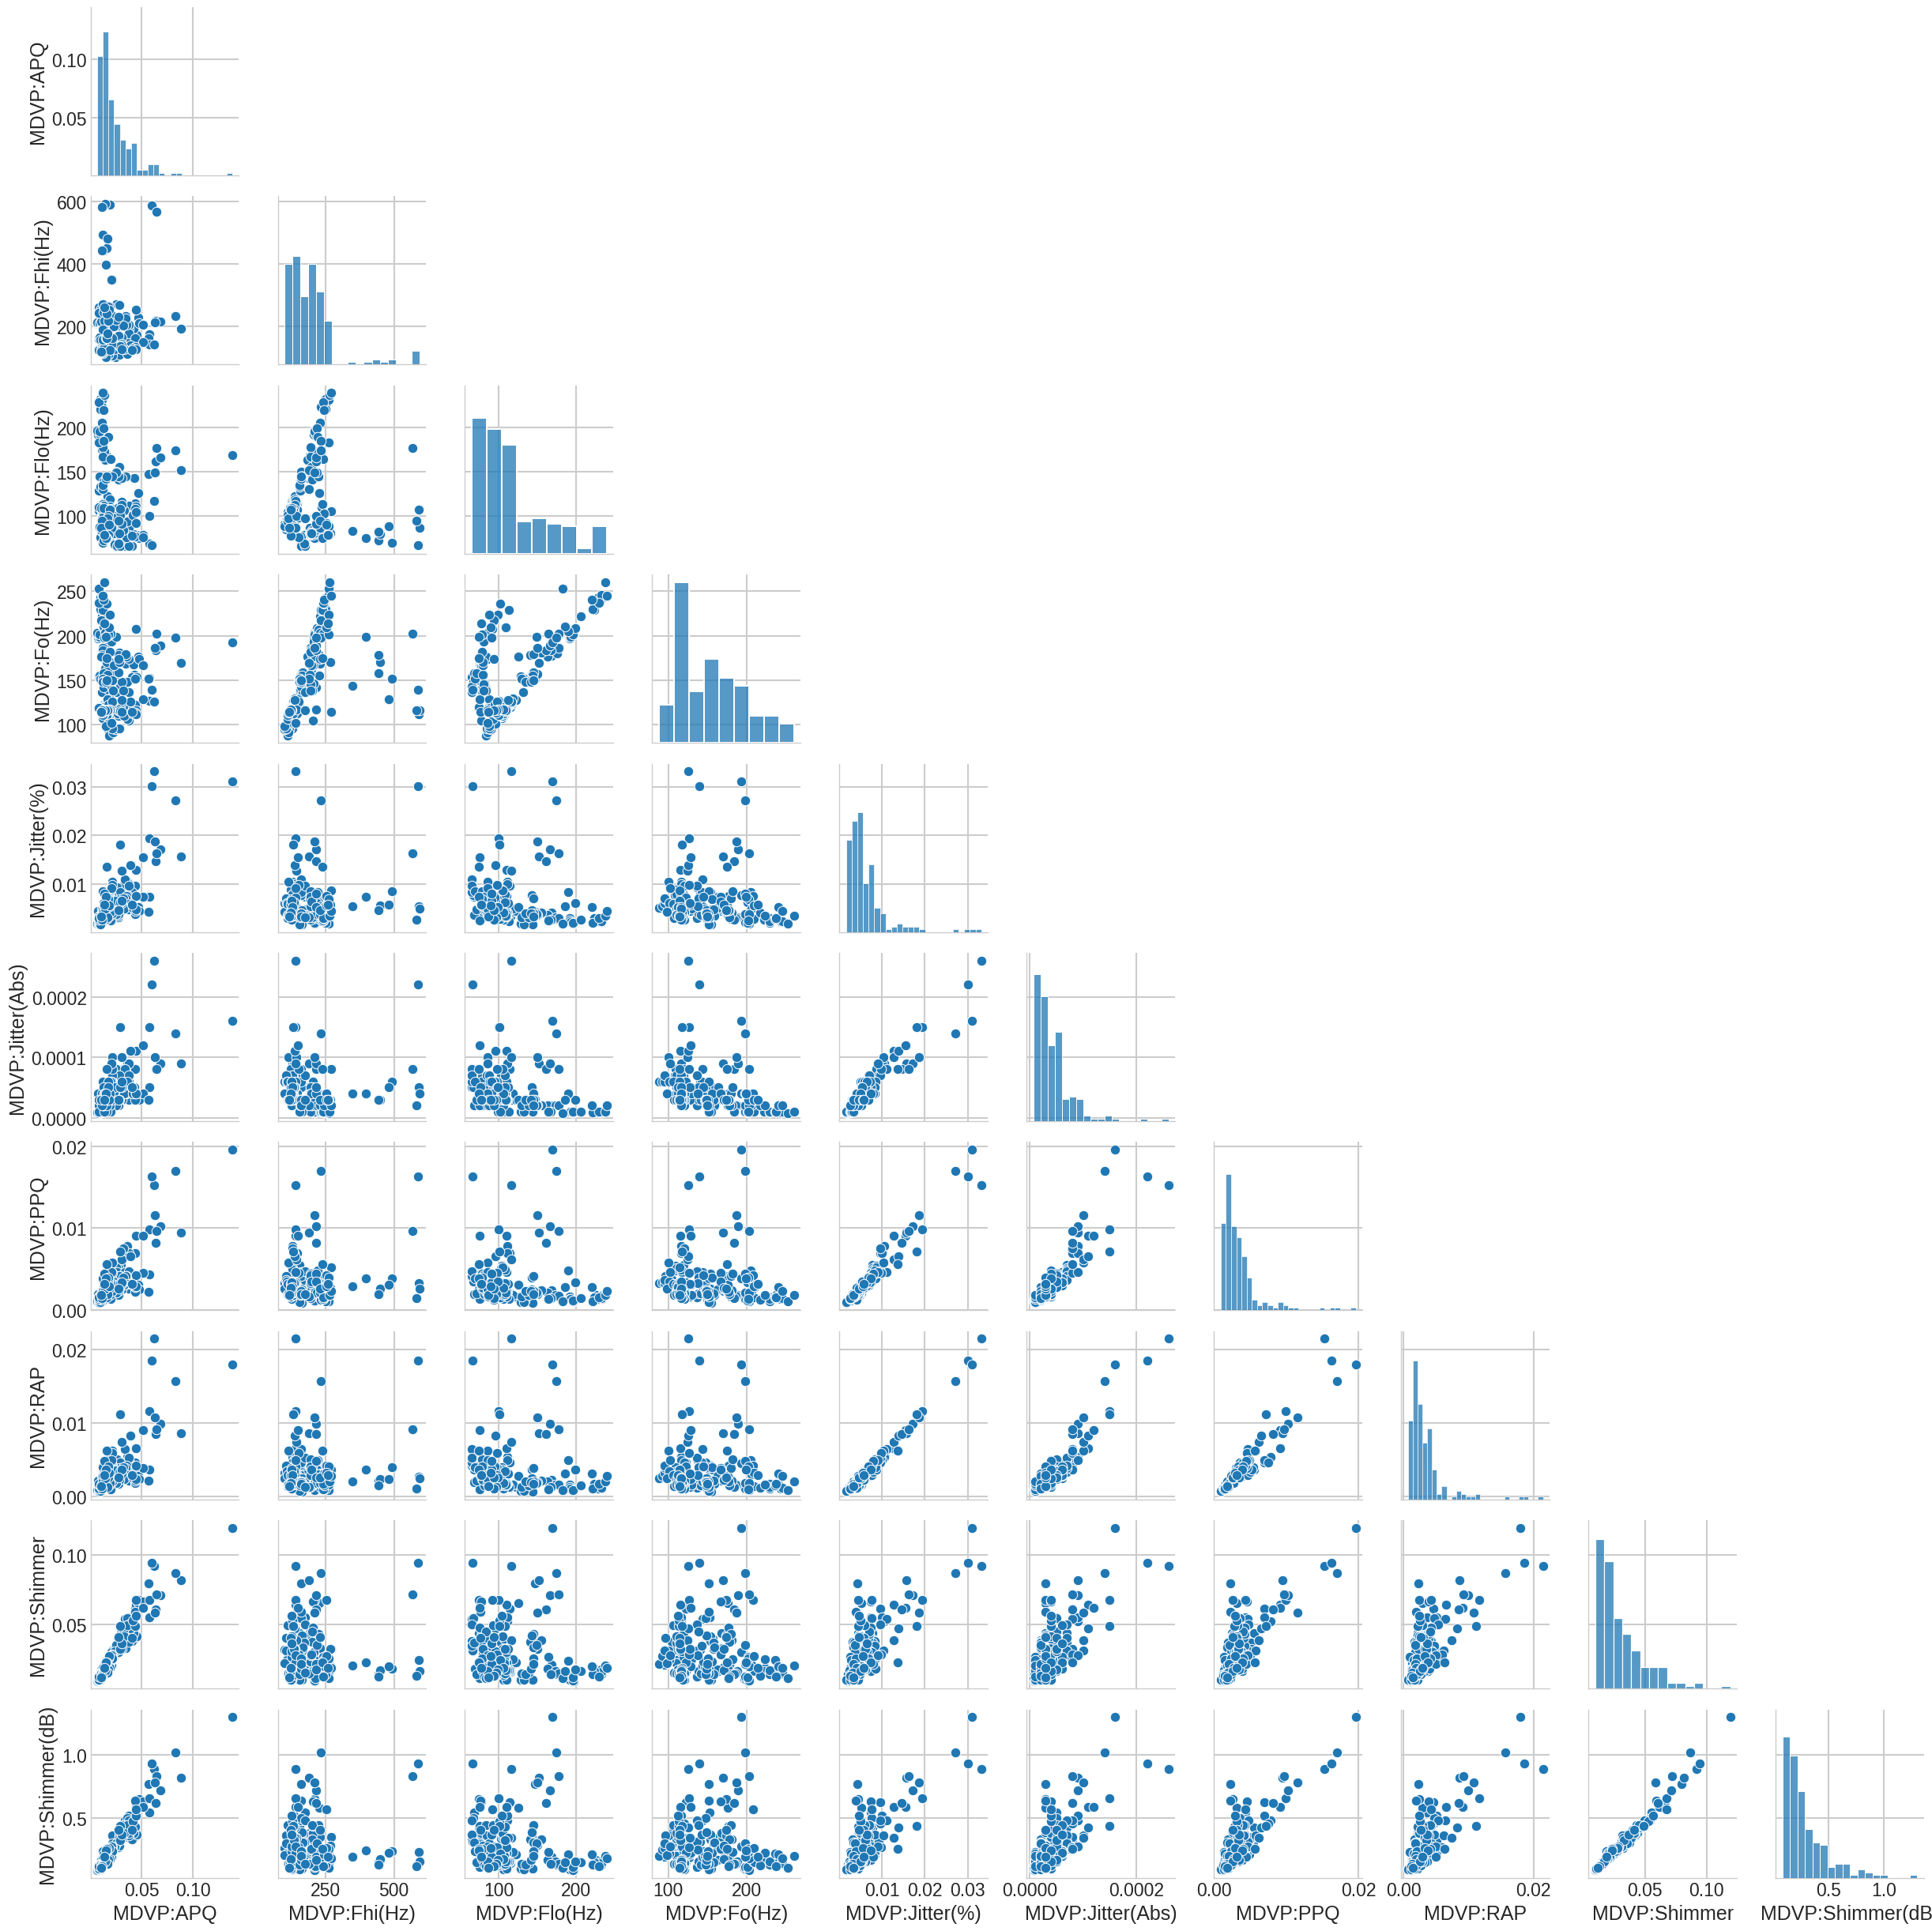

In [ ]:
# create a pairplot
pairplot = sns.pairplot(mdvp)

axes = pairplot.axes

# mask the upper triangle for simplicity
for i, j in zip(*np.triu_indices_from(axes, 1)):
    axes[i, j].set_visible(False)

plt.show()

In [ ]:
# [RAP & Jitter(%)] and [Shimmer & Shimmer(dB)] almost have a perfect linear relation

def check_linear_relation(feature, label):
  temp = df_copy.dropna()
  X = temp[feature]
  y = temp[label]

  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

  model = LinearRegression()
  model.fit(X_train, y_train)

  # predict on the test set
  y_pred = model.predict(X_test)

  # calculate R-squared
  r2 = r2_score(y_test, y_pred)
  print(feature, label)
  print("R-squared:", r2)

  # print eq
  print("Equation y={0:.4f}*x + {1:.4f}".format(model.coef_[0][0], model.intercept_[0]))

  impute_df = pd.DataFrame()
  impute_df['org'] = y
  impute_df['pre'] = model.predict(X)
  sns.regplot(impute_df, x='org', y='pre', line_kws=dict(color="r"))
  plt.show()

  return model.coef_[0][0], model.intercept_[0]

['MDVP:Jitter(%)'] ['MDVP:RAP']
R-squared: 0.9720670544755327
Equation y=0.6092*x + -0.0005


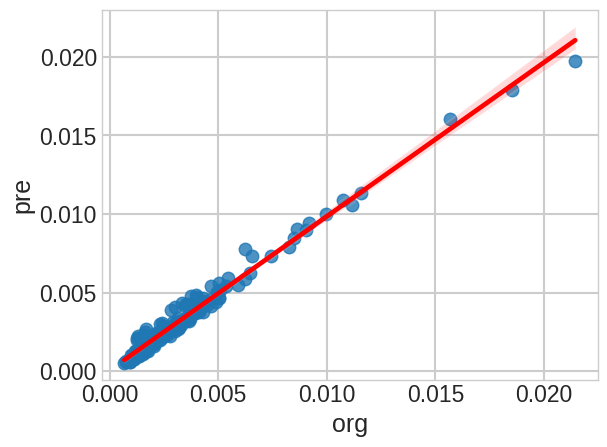

In [ ]:
coef, inter = check_linear_relation(['MDVP:Jitter(%)'], ['MDVP:RAP'])

In [ ]:
# satisfiable score
# impute the missing MDVP:RAP data

def custom_fill(row, fill_column, target_column, multiplier, constant):
    if pd.isna(row[fill_column]):
        return row[target_column] * multiplier + constant
    else:
        return row[fill_column]

# test the function
dummy_data = {
    'Column1': [1, 2, np.nan, 4, 5],
    'Column2': [np.nan, 1.5, 2.5, np.nan, 5.5],
    'Column3': [3, np.nan, 1, 2, np.nan]
}

dummy_df = pd.DataFrame(dummy_data)
dummy_df['Column3_filled'] = dummy_df.apply(lambda row: custom_fill(row, 'Column3', 'Column2', 2, 1), axis=1)

dummy_df

,Column1,Column2,Column3,Column3_filled
0,1.0,NaN,3.0,3.0
1,2.0,1.5,NaN,4.0
2,NaN,2.5,1.0,1.0
3,4.0,NaN,2.0,2.0
4,5.0,5.5,NaN,12.0


['MDVP:Shimmer(dB)'] ['MDVP:Shimmer']
R-squared: 0.9716016685744977
Equation y=0.0964*x + 0.0026


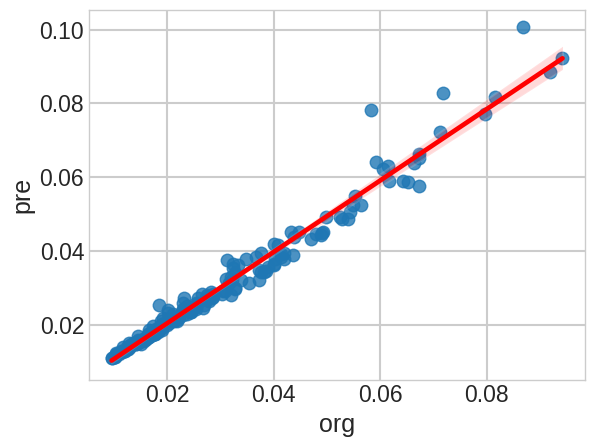

In [ ]:
# apply on acutal df
df_copy['MDVP:RAP'] = df_copy.apply(lambda row: custom_fill(row, 'MDVP:RAP', 'MDVP:Jitter(%)', coef, inter), axis=1)
assert df_copy['MDVP:RAP'].isna().sum() == 0

# do the same for [Shimmer & Shimmer(dB)]
coef, inter = check_linear_relation(['MDVP:Shimmer(dB)'], ['MDVP:Shimmer'])

In [ ]:
# satisfiable score
# impute the missing MDVP:Shimmer data

df_copy['MDVP:Shimmer'] = df_copy.apply(lambda row: custom_fill(row, 'MDVP:Shimmer', 'MDVP:Shimmer(dB)',  coef, inter), axis=1)
assert df_copy['MDVP:Shimmer'].isna().sum() == 0

df[df.isnull().any(axis=1)]

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE,DCAT
5,phon_R01_S01_6,120.552,131.162,NaN,0.00968,0.00008,0.00463,0.00750,0.01388,NaN,...,0.01222,21.378,True,NaN,0.825069,-4.242867,0.299111,2.187560,0.357775,N
16,phon_R01_S04_5,144.188,349.259,82.764,0.00544,0.00004,0.00211,0.00292,0.00632,0.02047,...,0.01859,22.333,True,0.567380,0.644692,-5.440040,0.239764,2.264501,0.218164,O
35,phon_R01_S07_6,201.464,210.565,195.708,0.00198,0.00001,NaN,0.00115,0.00314,0.01194,...,0.00135,31.732,False,0.344252,0.742737,-7.777685,0.170183,2.447064,0.057610,X
52,phon_R01_S13_5,128.001,138.052,122.080,0.00436,0.00003,0.00137,0.00166,0.00411,0.02297,...,0.00481,24.692,False,NaN,0.766204,-7.072419,0.220434,1.972297,0.119308,Q
151,phon_R01_S35_6,192.818,NaN,168.793,0.03107,0.00016,0.01800,0.01958,0.05401,0.11908,...,0.21713,8.441,True,0.625866,0.768320,-2.434031,0.450493,3.079221,0.527367,A


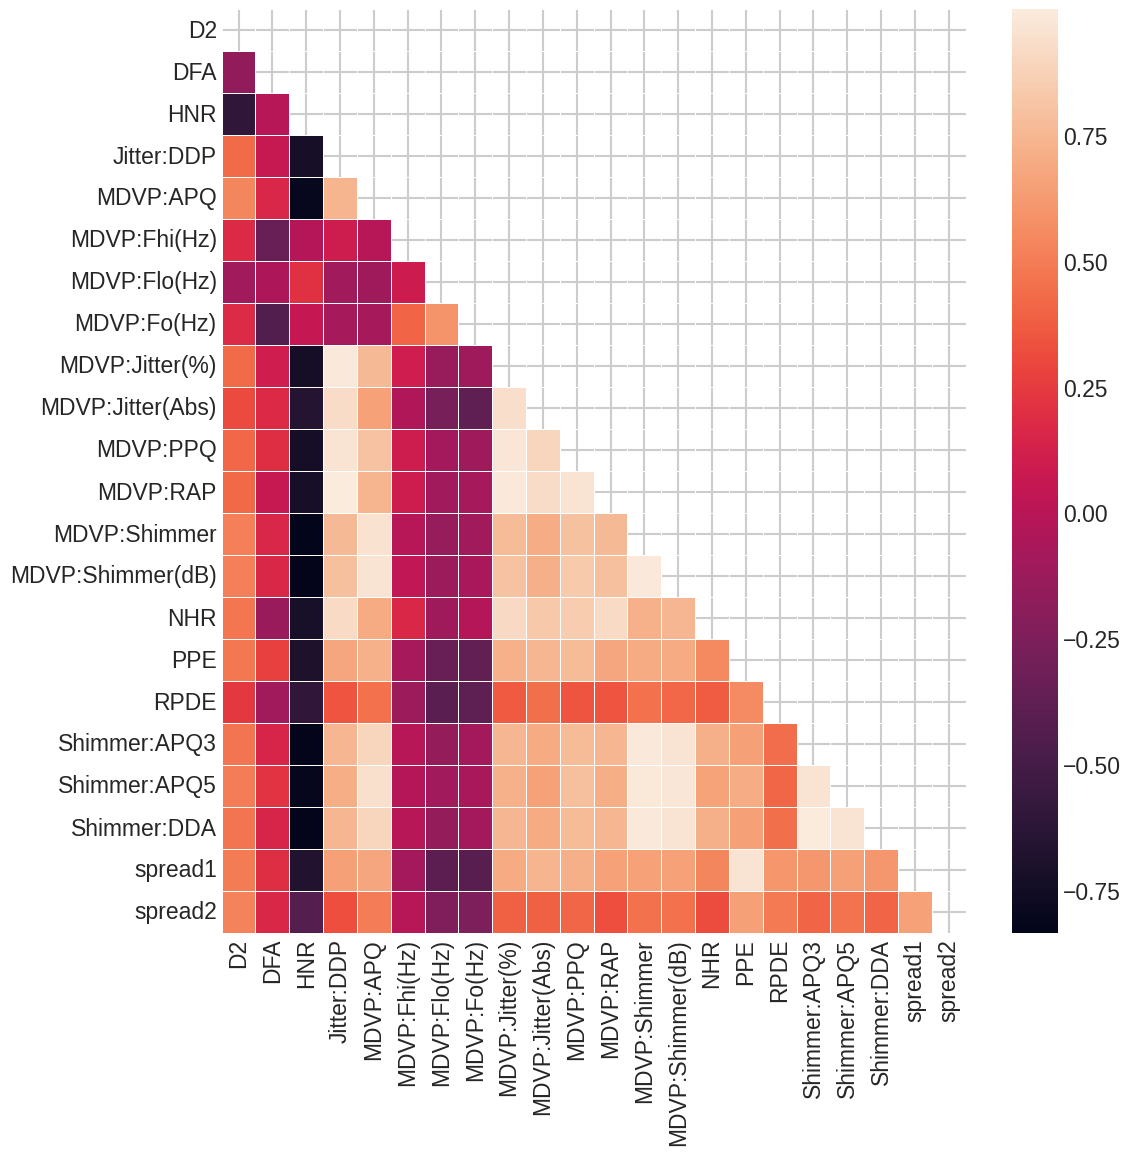

In [ ]:
# 1 done, 4 more to go

# check correlation with a heatmap
corr_matrix = df_copy.select_dtypes(include=['number']).corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(12, 12))
sns.heatmap(corr_matrix, linewidth=.5, mask=mask)
plt.show()

['MDVP:Shimmer'] ['Shimmer:DDA']
R-squared: 0.9500280790309023
Equation y=1.6249*x + -0.0009


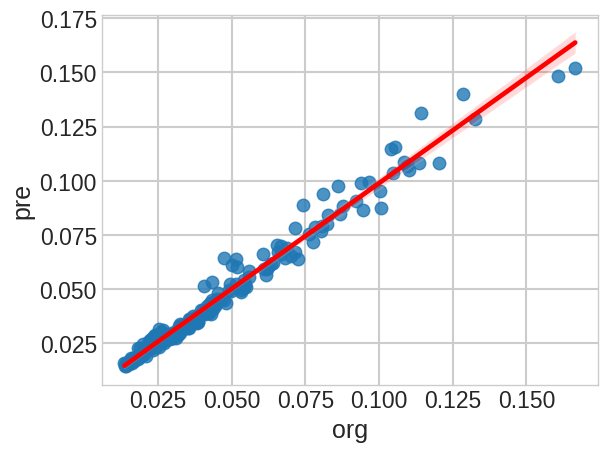

In [ ]:
# [Shimmer:DDA & MDVP:Shimmer] looks good

coef, inter = check_linear_relation(['MDVP:Shimmer'], ['Shimmer:DDA'])

In [ ]:
# satisfiable score
# impute the missing Shimmer:DDA data

df_copy['Shimmer:DDA'] = df_copy.apply(lambda row: custom_fill(row, 'Shimmer:DDA', 'MDVP:Shimmer', coef, inter), axis=1)
assert df_copy['Shimmer:DDA'].isna().sum() == 0

df_copy[df_copy.isnull().any(axis=1)]

,D2,DCAT,DFA,HNR,Jitter:DDP,MDVP:APQ,MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Fo(Hz),MDVP:Jitter(%),...,NHR,PPE,RPDE,Shimmer:APQ3,Shimmer:APQ5,Shimmer:DDA,name,spread1,spread2,status
5,2.187560,N,0.825069,21.378,0.01388,0.03243,131.162,NaN,120.552,0.00968,...,0.01222,0.357775,NaN,0.02328,0.03526,0.06985,phon_R01_S01_6,-4.242867,0.299111,True
52,1.972297,Q,0.766204,24.692,0.00411,0.01677,138.052,122.080,128.001,0.00436,...,0.00481,0.119308,NaN,0.01323,0.01072,0.03969,phon_R01_S13_5,-7.072419,0.220434,False
151,3.079221,A,0.768320,8.441,0.05401,0.13778,NaN,168.793,192.818,0.03107,...,0.21713,0.527367,0.625866,0.05647,0.07940,0.16942,phon_R01_S35_6,-2.434031,0.450493,True


In [ ]:
# I guess this is the limit of imputatin, unless I want some complex algorithms to involve like multinomial or multidimentional regression
# drop the three rows

df_copy.dropna(inplace=True)
assert df_copy.isna().sum().sum() == 0
df_copy.reset_index(drop=True, inplace=True)
print(df_copy.shape)

df.dropna(inplace=True)
assert df.isna().sum().sum() == 0
df.reset_index(drop=True, inplace=True)
print(df.shape)

(192, 25)
(190, 25)


## Data Exploration

In [ ]:
# there are two non-numeric columns
df[['name', 'DCAT']].head()

,name,DCAT
0,phon_R01_S01_1,N
1,phon_R01_S01_2,L
2,phon_R01_S01_3,M
3,phon_R01_S01_4,M
4,phon_R01_S01_5,L


In [ ]:
df.name.nunique()

190

In [ ]:
# the name column values are unique for each row
# which implies that it is likely a primary key to identify each row
# and should not be used as a feature for classification

df.drop('name', axis=1, inplace=True)
print(df.DCAT.nunique())
print(df.DCAT.unique())

df_copy.drop('name', axis=1, inplace=True)
print(df_copy.DCAT.nunique())
print(df_copy.DCAT.unique())

25
['N' 'L' 'M' 'Q' 'S' 'R' 'J' 'O' 'P' 'W' 'Y' 'Z' 'K' 'F' 'I' 'H' 'G' 'D'
 'E' 'A' 'C' 'U' 'T' 'V' 'B']
26
['N' 'L' 'M' 'Q' 'S' 'R' 'O' 'J' 'P' 'W' 'Y' 'Z' 'X' 'K' 'F' 'I' 'H' 'G'
 'D' 'E' 'A' 'C' 'U' 'T' 'V' 'B']


In [ ]:
# 26 is a bit too many to be considered as categorial representations
# and wait, there are only 26 alphabets in english and all 26 of them are used as some form of text representation?
# it is way too suspicious, it will be dropped

df.drop('DCAT', axis=1, inplace=True)
df_copy.drop('DCAT', axis=1, inplace=True)

In [ ]:
df.describe()

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE
count,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,...,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000
mean,154.145063,196.747326,115.790374,0.006108,0.000043,0.003250,0.003364,0.009752,0.029325,0.277747,...,0.023572,0.046515,0.024164,21.890468,0.498956,0.717275,-5.692054,0.225208,2.381608,0.205249
std,41.576359,91.777791,43.472502,0.004546,0.000034,0.002798,0.002509,0.008395,0.017850,0.181842,...,0.014977,0.029384,0.038402,4.311855,0.103963,0.054996,1.057993,0.082629,0.382957,0.086664
min,88.333000,102.145000,65.476000,0.001680,0.000007,0.000680,0.000920,0.002040,0.009540,0.085000,...,0.007190,0.013640,0.000650,8.867000,0.256570,0.574282,-7.964984,0.006274,1.423287,0.044539
25%,117.238000,134.759250,84.181500,0.003460,0.000020,0.001665,0.001865,0.005003,0.016473,0.148250,...,0.013075,0.024668,0.005980,19.197000,0.423579,0.674660,-6.445950,0.173935,2.097181,0.138601
50%,149.239500,174.402000,103.732500,0.004940,0.000030,0.002500,0.002680,0.007495,0.023020,0.221000,...,0.018125,0.038335,0.011635,22.075500,0.496717,0.721696,-5.722462,0.217525,2.363666,0.193985
75%,181.758000,223.311500,138.002750,0.007315,0.000058,0.003782,0.003938,0.011350,0.037650,0.349500,...,0.029272,0.059478,0.025815,25.097250,0.588759,0.760101,-5.081375,0.277329,2.637367,0.252296
max,260.105000,592.030000,239.170000,0.033160,0.000260,0.021440,0.016990,0.064330,0.094190,1.018000,...,0.088080,0.166540,0.314820,33.047000,0.685151,0.825288,-2.839756,0.434326,3.671155,0.457533


status
True     0.757895
False    0.242105
Name: proportion, dtype: float64


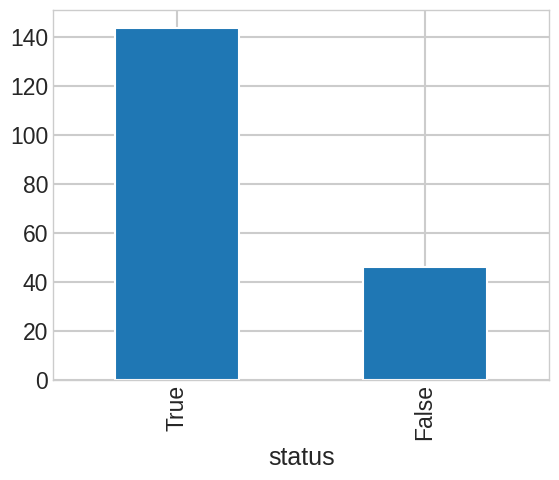

In [ ]:
# some columns (Fo, Fhi, Flo) have very high and large range compared to the rest

# see the status distribution
print(df.status.value_counts(normalize=True))
df.status.value_counts().plot(kind='bar')
plt.show()

In [ ]:
# stratify is recommended

## Data Visualization

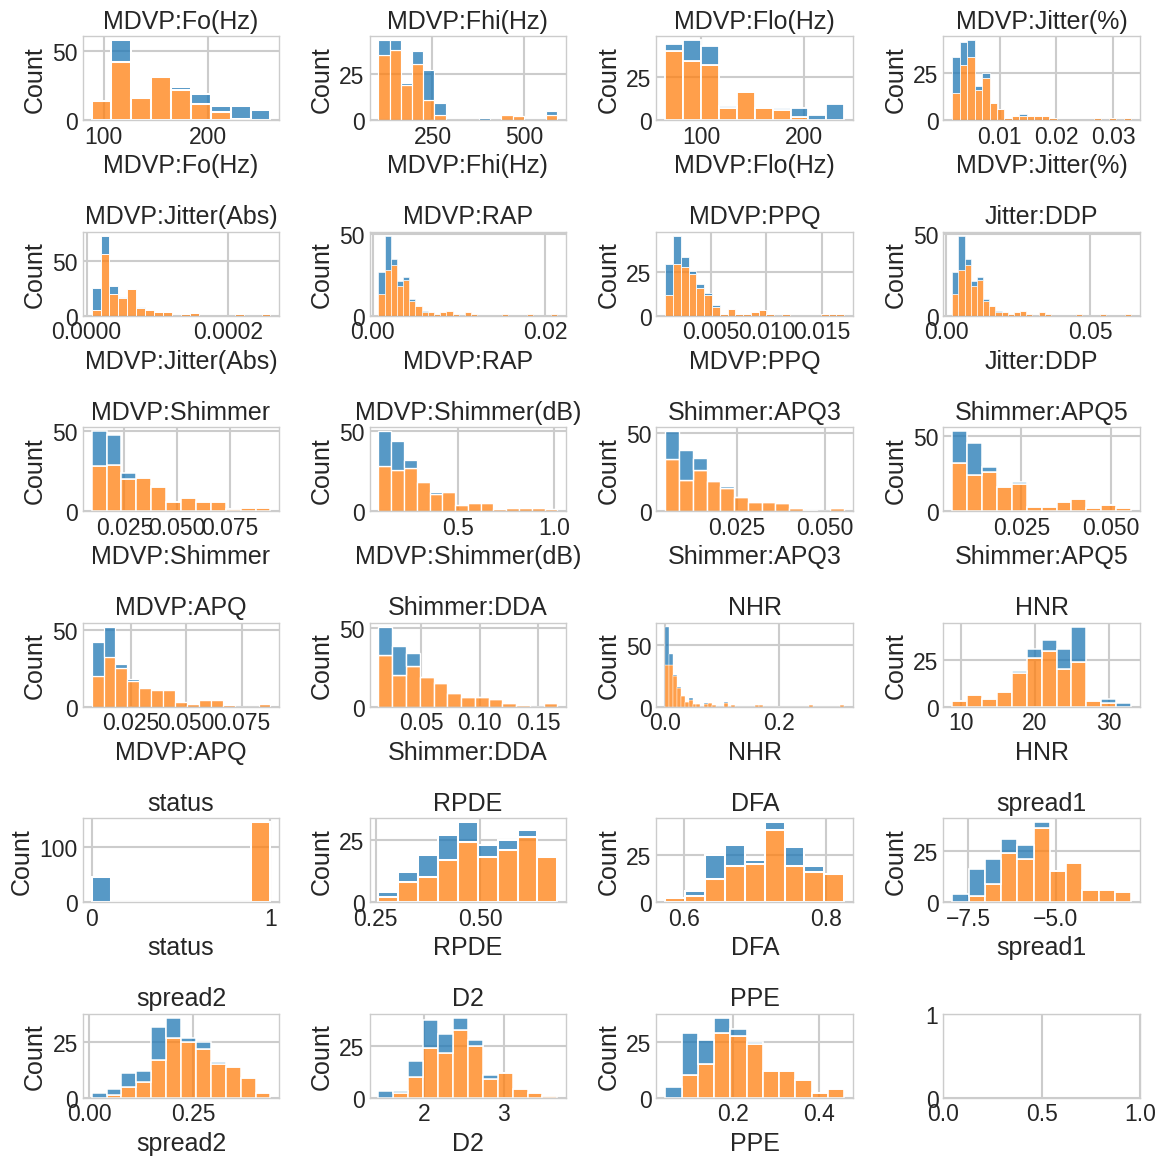

<Figure size 640x480 with 0 Axes>

In [ ]:
# view data distribution

fig, axes = plt.subplots(6, 4, figsize=(12, 12))

for i, col in enumerate(df.columns):
    row = i // 4
    col_num = i % 4
    sns.histplot(data=df, x=col, ax=axes[row, col_num], hue='status', multiple='stack', legend=False) #off legend for visbility; the more common color would be True(status 1)
    axes[row, col_num].set_title(col)

plt.tight_layout()
plt.show()
plt.savefig("feature_distribution.jpg")

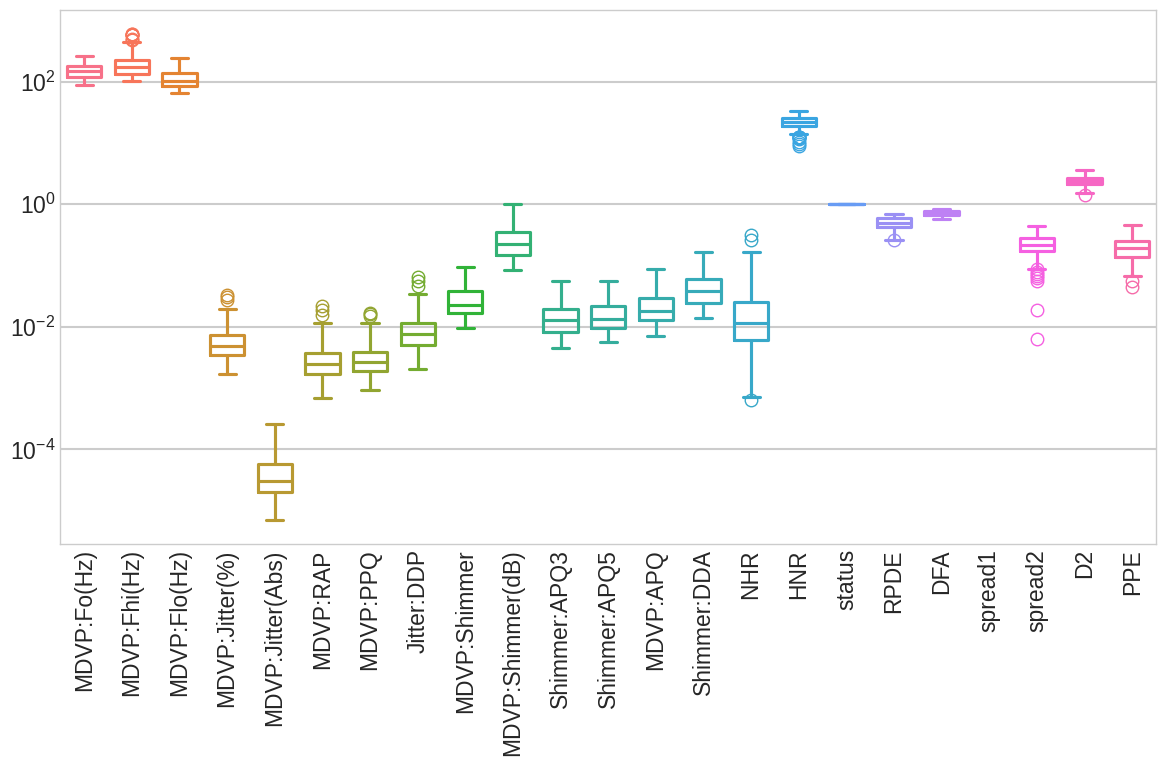

In [ ]:
# it seems most features (Shimmer, APQ, DDA) are skewed to the right
# while some (spread2, D2, PPE) have low normal distribution
# and some columns have visible outliers

fig, ax = plt.subplots(figsize=(12, 8))
sns.boxplot(df, log_scale=True, fill=False, gap=.1, ax=ax)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
# since outliers present, some features are skewed and some have different scale
# Robust Scaler should be used should scaling be needed except for DecisionTreeClassifier

## Feature Enginnering

In [ ]:
# the data has too many columns but not enough entries
# curse of dimentionality
# indicating the possibility of poor performance and more complexity
# there is a need to reduce the dimensions

# split the data first
# separate feature columns and the target column
feature_cols = [x for x in df.columns if x != 'status']
strat_shuff_split = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, test_idx = next(strat_shuff_split.split(df[feature_cols], df['status']))

# create the data sets
X_train = df.loc[train_idx, feature_cols]
y_train = df.loc[train_idx, 'status']

X_test = df.loc[test_idx, feature_cols]
y_test = df.loc[test_idx, 'status']

print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

status
True     0.759398
False    0.240602
Name: proportion, dtype: float64
status
True     0.754386
False    0.245614
Name: proportion, dtype: float64


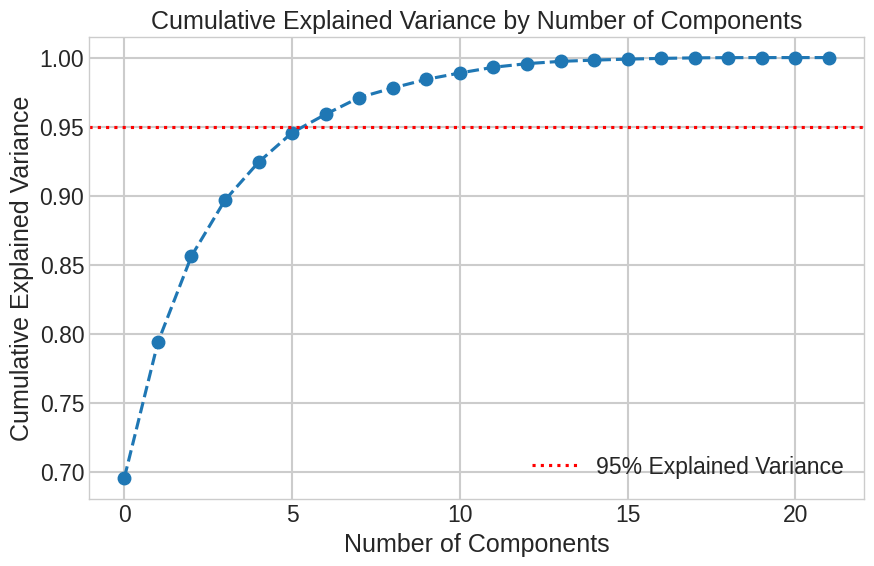

In [ ]:
# scale the data
scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# perform PCA only on train set to prevent data leakage
# raw pca to get a rough idea of explained variance ratio
pca = PCA()
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

# plot the explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance by Number of Components')
plt.axhline(y=0.95, color='r', linestyle=':', label='95% Explained Variance')
plt.legend()
plt.show()

In [ ]:
# taking 95% explained variance will leave us 7 columns and is suitable
# as the explained variance ratio flatten out after that
# and reducing from 23 to 7 components may double or even triple the processing speed

pca = PCA(n_components=0.95)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)
print("Total explained variance ratio:", np.sum(pca.explained_variance_ratio_).round(3))
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)

Total explained variance ratio: 0.959
Shape of X_train: (133, 7)
Shape of X_test: (57, 7)


In [ ]:
X_train_df = pd.DataFrame(X_train)
pca_df = pd.concat([X_train_df, y_train], axis=1)
pca_df.columns = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'status']
pca_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,status
0,8.881208,0.064465,-0.393254,0.303993,-0.677195,-0.510629,-0.167383,True
1,-1.300502,-0.365826,1.659716,2.367396,-0.084660,0.055668,-0.320533,NaN
2,0.859109,-0.934791,-1.640683,-0.442425,-0.183660,0.146563,-0.348253,True
3,0.942157,-1.038335,-0.536642,0.072401,-0.823492,-0.223588,-0.315065,NaN
4,-0.108021,0.080111,1.803363,-0.606601,-1.069599,0.328031,-0.441332,True


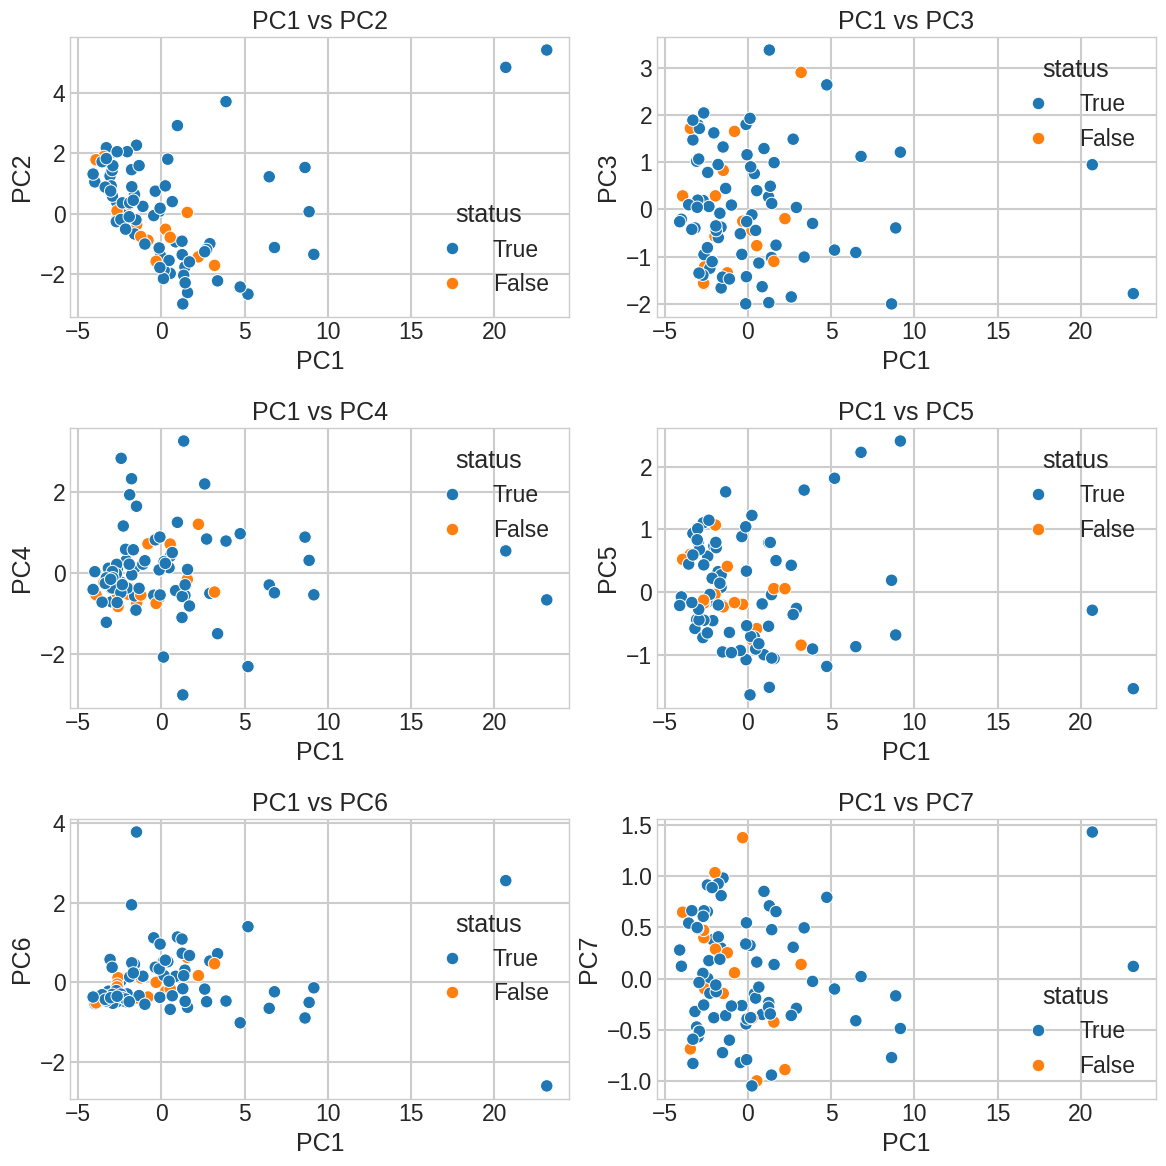

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
(ax1, ax2), (ax3, ax4), (ax5, ax6) = axes

sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='status', ax=ax1)
ax1.set_title('PC1 vs PC2')
sns.scatterplot(data=pca_df, x='PC1', y='PC3', hue='status', ax=ax2)
ax2.set_title('PC1 vs PC3')
sns.scatterplot(data=pca_df, x='PC1', y='PC4', hue='status', ax=ax3)
ax3.set_title('PC1 vs PC4')
sns.scatterplot(data=pca_df, x='PC1', y='PC5', hue='status', ax=ax4)
ax4.set_title('PC1 vs PC5')
sns.scatterplot(data=pca_df, x='PC1', y='PC6', hue='status', ax=ax5)
ax5.set_title('PC1 vs PC6')
sns.scatterplot(data=pca_df, x='PC1', y='PC7', hue='status', ax=ax6)
ax6.set_title('PC1 vs PC7')

plt.tight_layout()
plt.show()

In [ ]:
# the same could be tried for other pca combinations
# but from PCA1 against the rest, it seems no two pair from those is enough for the classification

# Build Decision Tree Model

In [ ]:
# train a raw tree to see the general result
t2_233523A_dt = tree.DecisionTreeClassifier(random_state=42)

t2_233523A_dt.fit(X_train, y_train)

# evaluate
def evaluate(model):
  y_pred_train = model.predict(X_train)
  y_pred_test = model.predict(X_test)

  train_report = classification_report(y_train, y_pred_train)
  test_report = classification_report(y_test, y_pred_test)

  print("Train Accuracy = ", model.score(X_train, y_train))
  print(train_report)
  print()
  print("Test Accuracy = ", model.score(X_test, y_test))
  print(test_report)

  return y_pred_train, y_pred_test

t2_233523A_dt.fit(X_train, y_train)
y_pred_train, y_pred_test = evaluate(t2_233523A_dt)

Train Accuracy =  1.0
              precision    recall  f1-score   support

       False       1.00      1.00      1.00        32
        True       1.00      1.00      1.00       101

    accuracy                           1.00       133
   macro avg       1.00      1.00      1.00       133
weighted avg       1.00      1.00      1.00       133


Test Accuracy =  0.8070175438596491
              precision    recall  f1-score   support

       False       0.64      0.50      0.56        14
        True       0.85      0.91      0.88        43

    accuracy                           0.81        57
   macro avg       0.74      0.70      0.72        57
weighted avg       0.80      0.81      0.80        57



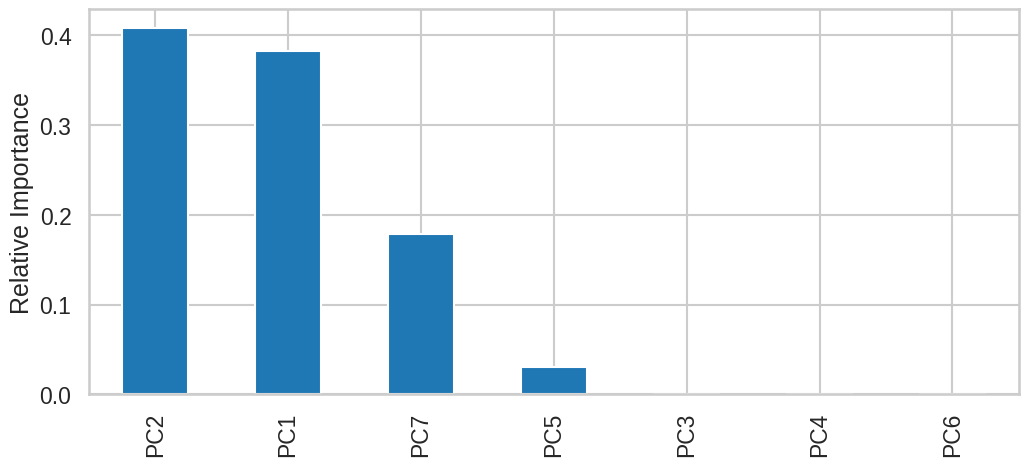

In [ ]:
# totally overfitted on the train set
# 0.81 accuracy on test set is okay, but the model performs poorly for 'False' status across all 3 scores
# this is probably because the original data iself only has 25% False status while the remaining 75% is 'True' status

# visualize the feature importance
feature_imp = pd.Series(t2_233523A_dt.feature_importances_, index=pca_df.columns[:7]).sort_values(ascending=False)
fig = plt.figure(figsize=(12,5))
ax = feature_imp.plot(kind='bar')
ax.set(ylabel='Relative Importance')
plt.show()

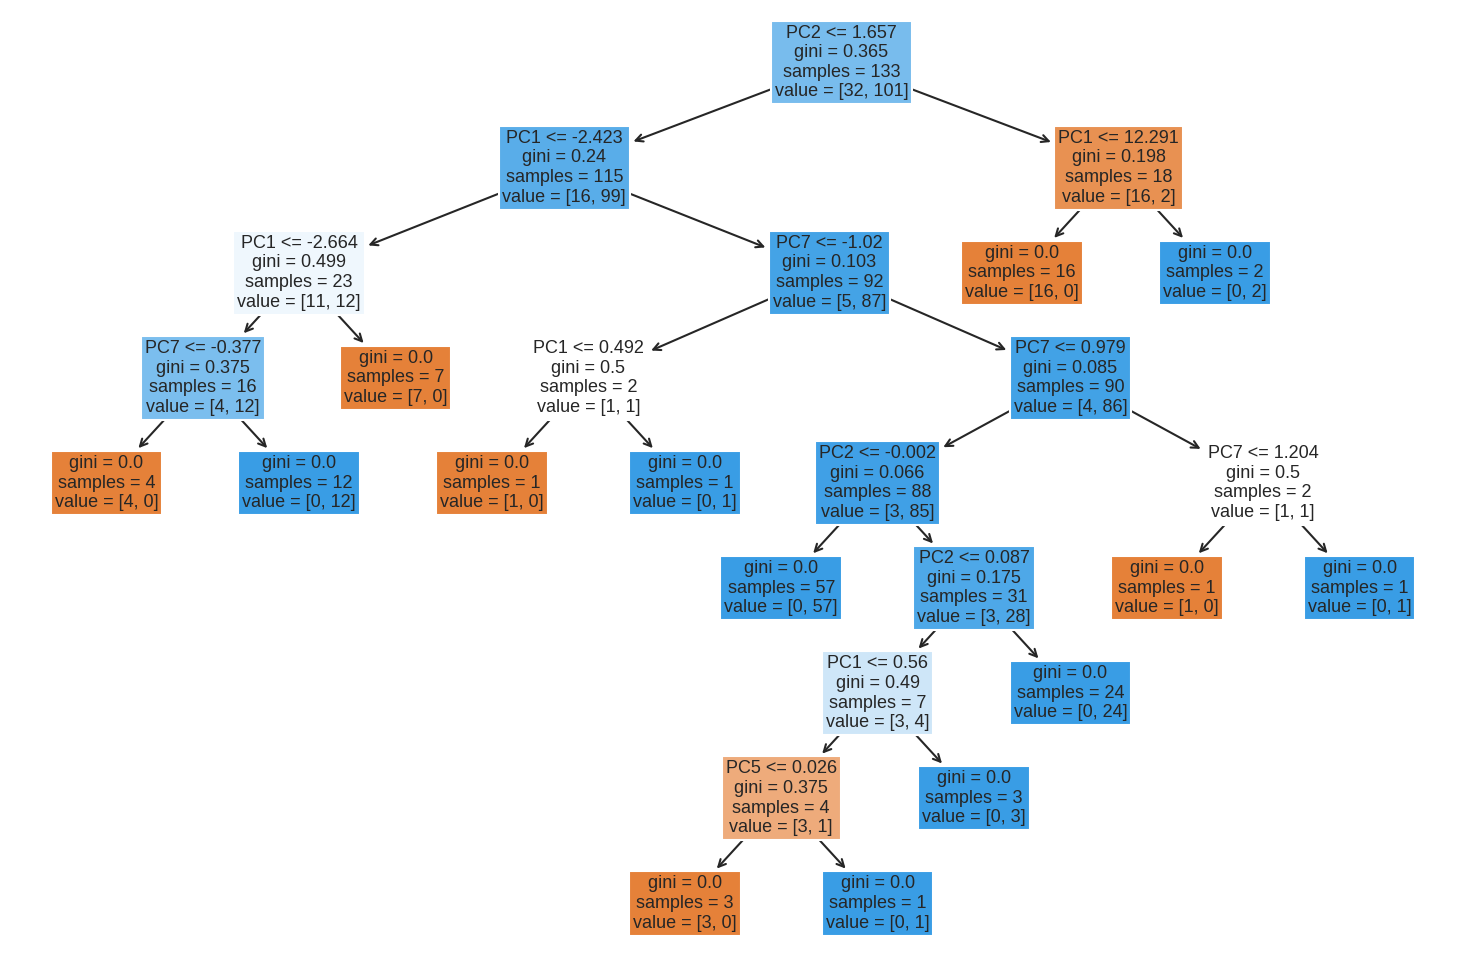

In [ ]:
# interesting; the last 3 columns were untouched

# see the tree
plt.figure(figsize=(15, 10))
tree.plot_tree(t2_233523A_dt, feature_names=pca_df.columns[:7], filled=True)
plt.tight_layout()
plt.show()

In [ ]:
# interpretability is lost as PCA was used

print("Raw Tree Model")
print("Max depth: ", t2_233523A_dt.get_depth())
print("Number of leaves: ", t2_233523A_dt.get_n_leaves())

Raw Tree Model
Max depth:  8
Number of leaves:  14


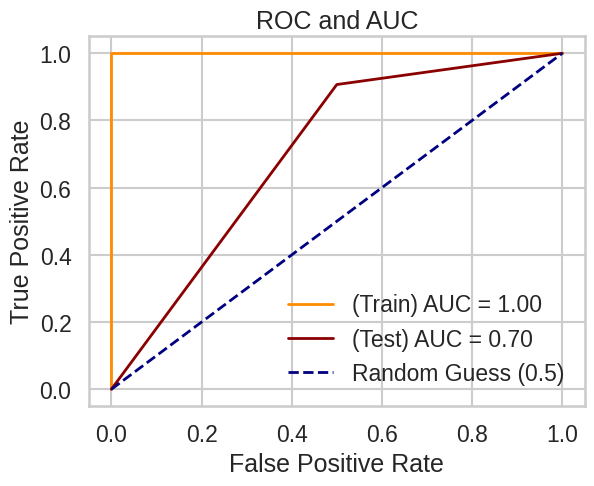

In [ ]:
# 8 depths and 14 leaves for around 190 rows of data
# quite a complex tree

# let us see the roc curve
def roc(model):
  y_probs_train = model.predict_proba(X_train)[:, 1]
  fpr, tpr, threshold = roc_curve(y_train, y_probs_train)
  train_roc_auc = auc(fpr, tpr)
  plt.figure()
  plt.plot(fpr,tpr, color="darkorange", lw=2, label="(Train) AUC = %0.2f" % train_roc_auc)

  y_probs = model.predict_proba(X_test)[:, 1]
  fpr, tpr, threshold = roc_curve(y_test, y_probs)
  test_roc_auc = auc(fpr, tpr)
  plt.plot(fpr,tpr, color="darkred", lw=2, label="(Test) AUC = %0.2f" % test_roc_auc)
  plt.xlabel("False Positive Rate")
  plt.ylabel("True Positive Rate")
  plt.title("ROC and AUC")

  plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess (0.5)')
  plt.legend(loc="lower right")
  plt.show()

  return y_probs_train, y_probs, train_roc_auc, test_roc_auc

y_probs_train, y_probs_test, train_auc, test_auc = roc(t2_233523A_dt)

In [ ]:
# totally overfitted

# record the results before optimization
summary = pd.DataFrame()
def record_results(y_true, y_pred, auc, label):
  return pd.Series({
      'accuracy':accuracy_score(y_true, y_pred),
      'precision': precision_score(y_true, y_pred),
      'recall': recall_score(y_true, y_pred),
      'f1': f1_score(y_true, y_pred),
      'auc': auc},
      name=label).rename_axis("metric")

train_error = pd.concat([record_results(y_train, y_pred_train, train_auc, 'dt_train')], axis=1)
test_error = pd.concat([record_results(y_test, y_pred_test, test_auc, 'dt_test')], axis=1)
summary = pd.concat([summary, train_error, test_error], axis=1)
summary

,dt_train,dt_test
metric,,
accuracy,1.0,0.807018
precision,1.0,0.847826
recall,1.0,0.906977
f1,1.0,0.876404
auc,1.0,0.703488


In [ ]:
# try GridSearch to optimize
params_dt = {
             'max_depth': [2, 3, 4, 5],
             'min_samples_leaf': [3, 4],
             'max_features': [0.8, 0.9],
             'min_samples_split': [2, 3]
            }

t2_233523A_dt_grid = GridSearchCV(t2_233523A_dt, params_dt, cv=5, scoring='accuracy', n_jobs=-1)
t2_233523A_dt_grid.fit(X_train, y_train)
y_pred_train, y_pred_test = evaluate(t2_233523A_dt_grid)

Train Accuracy =  0.924812030075188
              precision    recall  f1-score   support

       False       0.96      0.72      0.82        32
        True       0.92      0.99      0.95       101

    accuracy                           0.92       133
   macro avg       0.94      0.85      0.89       133
weighted avg       0.93      0.92      0.92       133


Test Accuracy =  0.8421052631578947
              precision    recall  f1-score   support

       False       0.73      0.57      0.64        14
        True       0.87      0.93      0.90        43

    accuracy                           0.84        57
   macro avg       0.80      0.75      0.77        57
weighted avg       0.83      0.84      0.84        57



In [ ]:
# the test accuracy did not increase, but the model was less overfitted

best_model = t2_233523A_dt_grid.best_estimator_
print("Best Model")
print("Number of leaves: ", best_model.get_n_leaves())
print("Best params: ", t2_233523A_dt_grid.best_params_)

Best Model
Number of leaves:  6
Best params:  {'max_depth': 3, 'max_features': 0.9, 'min_samples_leaf': 3, 'min_samples_split': 2}


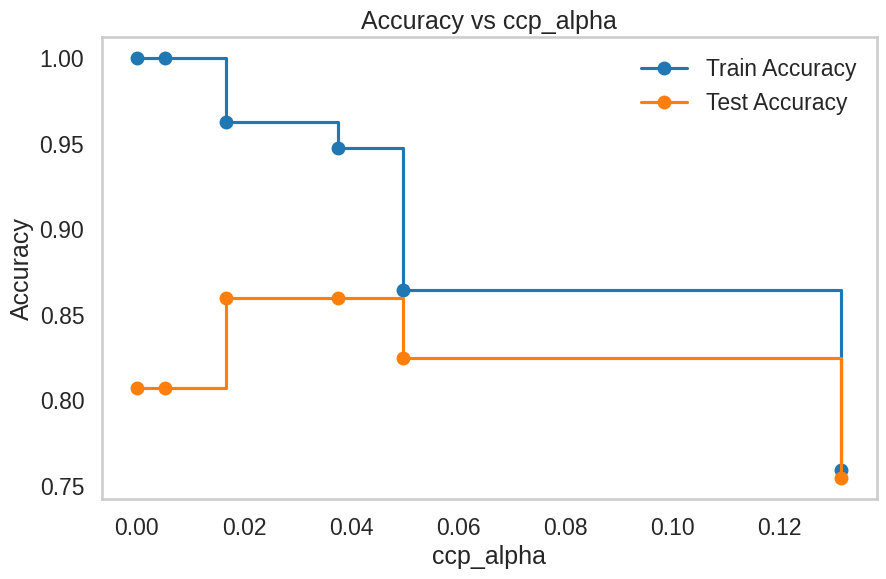

Best ccp_alpha: 0.01670843776106934
Accuracy of pruned tree: 0.8421


In [ ]:
# perform post-pruning
# Apply cost complexity pruning (Post-pruning)
path = best_model.cost_complexity_pruning_path(X_train, y_train)  # Get the effective alphas and corresponding total leaf impurities
ccp_alphas, impurities = path.ccp_alphas, path.impurities

# Train decision trees using different values of ccp_alpha
trees = []
for ccp_alpha in ccp_alphas:
    clf = tree.DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alpha)
    clf.fit(X_train, y_train)
    trees.append(clf)

# Calculate the accuracy of each pruned tree
train_acc = [accuracy_score(y_train, clf.predict(X_train)) for clf in trees]
test_acc = [accuracy_score(y_test, clf.predict(X_test)) for clf in trees]

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(ccp_alphas, train_acc, marker='o', label='Train Accuracy', drawstyle="steps-post")
plt.plot(ccp_alphas, test_acc, marker='o', label='Test Accuracy', drawstyle="steps-post")
plt.xlabel('ccp_alpha')
plt.ylabel('Accuracy')
plt.title('Accuracy vs ccp_alpha')
plt.legend()
plt.grid()
plt.show()

# Choose the best alpha based on the results and retrain the model
best_alpha = ccp_alphas[test_acc.index(max(test_acc))]
t2_233523A_best_dt = tree.DecisionTreeClassifier(max_depth=3, max_features=0.9, min_samples_leaf=3, min_samples_split=2, random_state=42, ccp_alpha=best_alpha)
t2_233523A_best_dt.fit(X_train, y_train)

# Get the accuracy of the pruned tree
y_pred_pruned = t2_233523A_best_dt.predict(X_test)
accuracy_pruned = accuracy_score(y_test, y_pred_pruned)
print(f"Best ccp_alpha: {best_alpha}")
print(f"Accuracy of pruned tree: {accuracy_pruned:.4f}")

In [ ]:
y_pred_train, y_pred_test = evaluate(t2_233523A_best_dt)

Train Accuracy =  0.9172932330827067
              precision    recall  f1-score   support

       False       0.89      0.75      0.81        32
        True       0.92      0.97      0.95       101

    accuracy                           0.92       133
   macro avg       0.91      0.86      0.88       133
weighted avg       0.92      0.92      0.91       133


Test Accuracy =  0.8421052631578947
              precision    recall  f1-score   support

       False       0.73      0.57      0.64        14
        True       0.87      0.93      0.90        43

    accuracy                           0.84        57
   macro avg       0.80      0.75      0.77        57
weighted avg       0.83      0.84      0.84        57



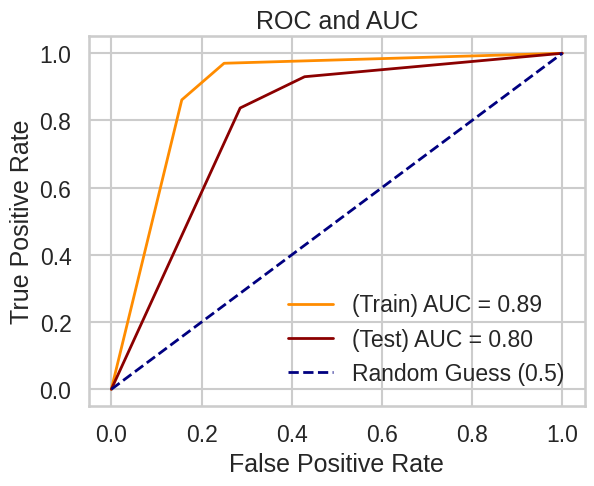

In [ ]:
# slightly less overfitted, same test accuracy

y_prob_train, y_prob_test, train_auc, test_auc = roc(t2_233523A_best_dt)

In [ ]:
# record results
train_error = pd.concat([record_results(y_train, y_pred_train, train_auc, 'dt_best_train')], axis=1)
test_error = pd.concat([record_results(y_test, y_pred_test, test_auc, 'dt_best_test')], axis=1)
summary = pd.concat([summary, train_error, test_error], axis=1)
summary

,dt_train,dt_test,dt_best_train,dt_best_test
metric,,,,
accuracy,1.0,0.807018,0.917293,0.842105
precision,1.0,0.847826,0.924528,0.869565
recall,1.0,0.906977,0.970297,0.930233
f1,1.0,0.876404,0.946860,0.898876
auc,1.0,0.703488,0.892017,0.797342


In [ ]:
def cross_val(model):
  cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
  print("CV Scores:", cv_scores)
  print("Mean CV Score:", cv_scores.mean())
  return cv_scores

cv_scores = cross_val(t2_233523A_best_dt)

CV Scores: [0.81481481 0.85185185 0.81481481 0.84615385 0.88461538]
Mean CV Score: 0.8424501424501425


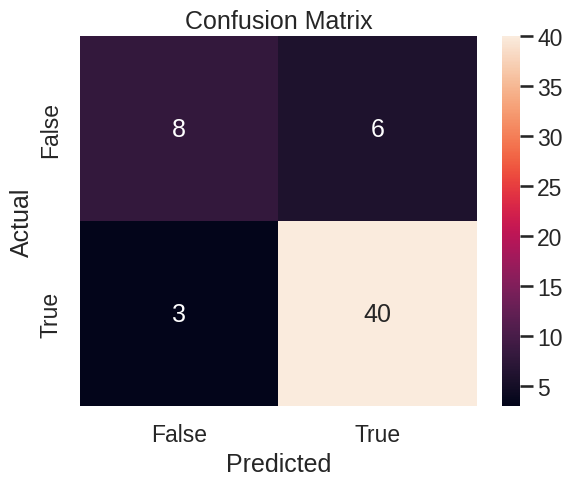

In [ ]:
# Confusion Matrix Map
def confusion(y_test, y_pred):
  cm = confusion_matrix(y_test, y_pred_test)
  sns.set_context('talk')
  ax = sns.heatmap(cm, annot=True, fmt='d')
  labels = ['False', 'True']
  ax.set_ylabel('Actual')
  ax.set_xlabel('Predicted')
  ax.set_xticklabels(labels)
  ax.set_yticklabels(labels)
  plt.title('Confusion Matrix')
  plt.show()
  return cm

cm = confusion(y_test, y_pred_test)

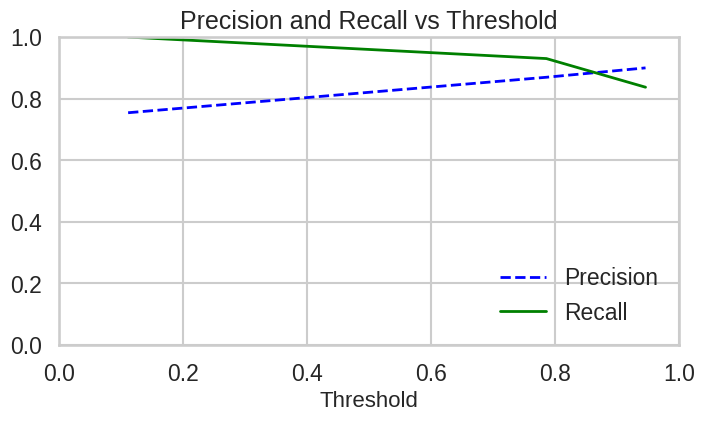

In [ ]:
# the overall scores and the overfitness are all now okay
# but the model is performing quite poorly on 'False' status class in unseen data
# this is probably because the original dataset has low instances of the 'False' status

# adjust impurity threshold value
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_test)

def plot_precision_recall_curve(precisions, recalls, thresholds):
  plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
  plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
  plt.xlabel("Threshold", fontsize=16)
  plt.legend(loc="upper left", fontsize=16)
  plt.xlim([0, 1])
  plt.ylim([0, 1])

plt.figure(figsize=(8, 4))
plot_precision_recall_curve(precisions, recalls, thresholds)
plt.title("Precision and Recall vs Threshold")
plt.legend(loc='lower right')
plt.show()

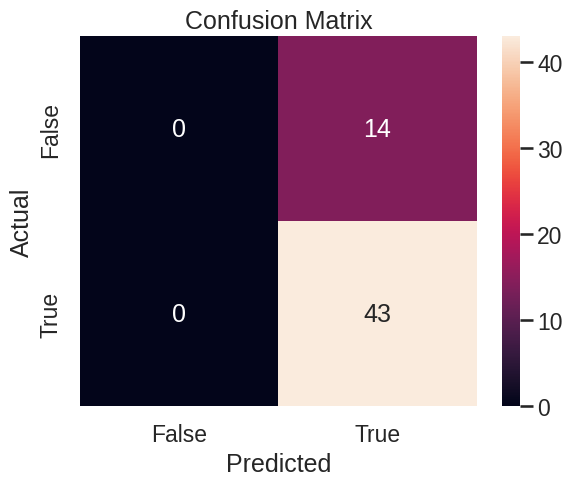

In [ ]:
y_pred_test = (y_prob_test >= 0.1).astype(int)
cm = confusion(y_test, y_pred_test)

In [ ]:
def measure_error(y_true, y_pred, label):
  return pd.Series({'accuracy':accuracy_score(y_true, y_pred),
  'precision': precision_score(y_true, y_pred),
  'recall': recall_score(y_true, y_pred),
  'f1': f1_score(y_true, y_pred)},
  name=label)

test_error = pd.concat([measure_error(y_test, y_pred_test, 'test')], axis=1)
test_error

,test
accuracy,0.754386
precision,0.754386
recall,1.000000
f1,0.860000


In [ ]:
# only when the threshold is set to >= 0.1, the recall socre has increased.
# the model can now predict all 43 positive status cases
# but it has become a dumb model that just keeps outputting True status for all incoming data
# the scores of other metrics are badly affected as well

# Summary of Decision Tree Model

In [ ]:
summary

,dt_train,dt_test,dt_best_train,dt_best_test
accuracy,1.0,0.807018,0.917293,0.842105
precision,1.0,0.847826,0.924528,0.869565
recall,1.0,0.906977,0.970297,0.930233
f1,1.0,0.876404,0.946860,0.898876
auc,1.0,0.703488,0.892017,0.797342


In [ ]:
summary

,dt_train,dt_test,dt_best_train,dt_best_test
metric,,,,
accuracy,1.0,0.807018,0.917293,0.842105
precision,1.0,0.847826,0.924528,0.869565
recall,1.0,0.906977,0.970297,0.930233
f1,1.0,0.876404,0.946860,0.898876
auc,1.0,0.703488,0.892017,0.797342


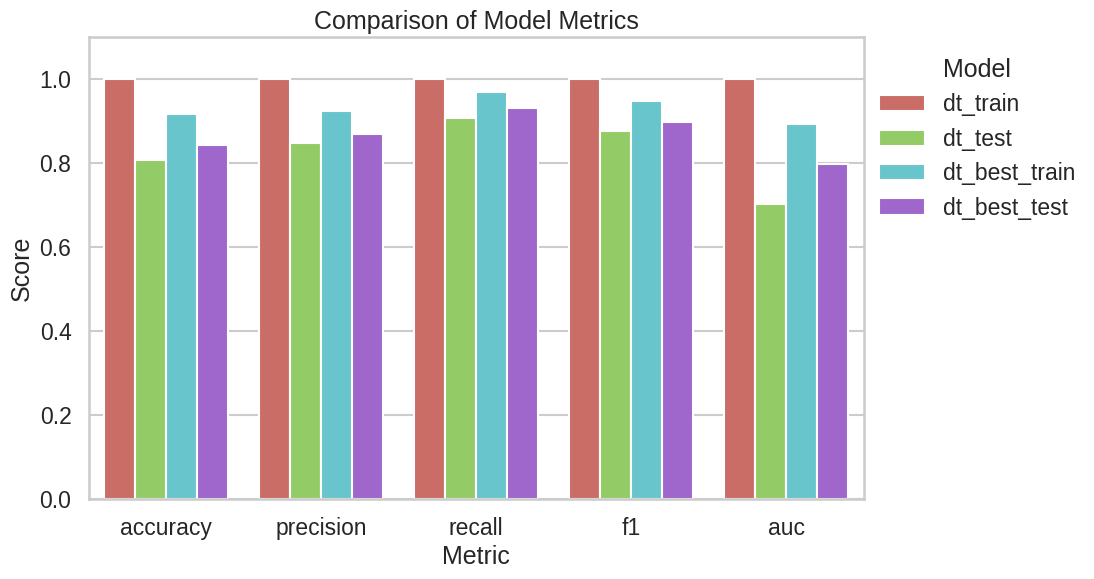

In [ ]:
# Melting the DataFrame for seaborn
df_melted = summary.reset_index().melt(id_vars=["metric"], var_name="Model", value_name="Score")

# Plotting the clustered vertical bars
plt.figure(figsize=(10, 6))
sns.barplot(x="metric", y="Score", hue="Model", data=df_melted, palette="hls")
plt.title("Comparison of Model Metrics")
plt.ylabel("Score")
plt.ylim(0.7, 1.1)
plt.xlabel("Metric")
plt.legend(title="Model", loc='upper right', bbox_to_anchor=(1.3, 1))
plt.show()

In [ ]:
# it is so sad to set a word limit on my thoughts that i had to write the full details as i wished.
# kindly use the second version for marking purposes within 150 word limit should the first one be rejected

[319 words]
1.   DecisionTrees are useful for classification tasks, but they tend to overfit if the nodes and branches are left uncontrolled.
2.   This is demonstrated in the raw tree, which has a good 0.82 accuracy score on test data, but a full 1.0 across all metrics for the training set.
3.   This is usually solved through GridSearchCV, which limits the range of max_depth, min_sample_leaf, min_sample_split etc., after which the accuracy became 0.92 on trained data and 0.84 on test data.
4.   It is safe to say the CV worked well as the model became less overfitted and the accuracy increased as well.
5.   This is called pre-pruning as the hyperparameters are brute-forced and optimized through training multiple models.
6.   There is also post-pruning, where each node of the tree are analyzed and cut or maintained through trial-and-error of its effect on test accuracy.
7.   Post-pruning is done to the best model of the GridSearchCV to further deal with overfitting, reducing train-set accuracy by 0.0075. This improves the generalization of the model on new, unseen data
8.   As shown in the above bar graph, the default DecisionTreeClassifier has good-enough scores on unseen data but is 100% overfitted, where as the optimized tree after GridSearchCV and post-pruning perfoms better on test data as well as having lower variance.
9.   Referring to the classification_report and confusion_maxtix from earlier, it is seen that the model performs poorly on unseen status 'False' class (recall=0.57), probably due to the imbalanced entries in the original data (~25% False, ~75% True).
10.  As this is a disease classification, should a higher recall is required, the decision threshold can be adjusted as demonstrated at the expense of other metrics.
11.  Although the optimization of DecisionTree can be done during and after training the model, it is better to perform regularizaiton of data before training the model, such as PCA analysis (especially recommended for this case as the given data has 'curse of dimentionality')

[114 words]
Decision Trees are effective for classification but prone to overfitting if not properly controlled. Initially, a raw tree showed 0.82 accuracy on test data but overfitted with a perfect 1.0 accuracy on training data. To address this, GridSearchCV was used for pre-pruning by optimizing hyperparameters like max_depth and min_samples_split, which improved test accuracy to 0.84 while reducing overfitting. Post-pruning further refined the model by trimming nodes based on their impact on test accuracy. Despite improvements, the model struggled with imbalanced data, particularly in recalling the 'False' class. For better recall in disease classification, adjusting the decision threshold or performing data regularization like PCA is advisable, especially in cases with high dimensionality.

# Build Ensemble Model

In [ ]:
# predicting diseases require a highly complex and accurate model to correctly identify individual cases

# for this Parkinson disease
# RandomForest is suitable to introduce double randomness and reduce variance
# Adaptive Boosting perfroms well on skewed label due to its continued focus on pervious errors
# SVM is also good in dealing with multi-dimentional data

# thus, the best ensemble method would be to stack those three models to obtain maximum performance

In [ ]:
# raw random forest
t2_233523A_rf = RandomForestClassifier(random_state=42)
t2_233523A_rf.fit(X_train, y_train)

y_pred_train, y_pred_test = evaluate(t2_233523A_rf)

Train Accuracy =  1.0
              precision    recall  f1-score   support

       False       1.00      1.00      1.00        32
        True       1.00      1.00      1.00       101

    accuracy                           1.00       133
   macro avg       1.00      1.00      1.00       133
weighted avg       1.00      1.00      1.00       133


Test Accuracy =  0.8771929824561403
              precision    recall  f1-score   support

       False       0.82      0.64      0.72        14
        True       0.89      0.95      0.92        43

    accuracy                           0.88        57
   macro avg       0.85      0.80      0.82        57
weighted avg       0.87      0.88      0.87        57



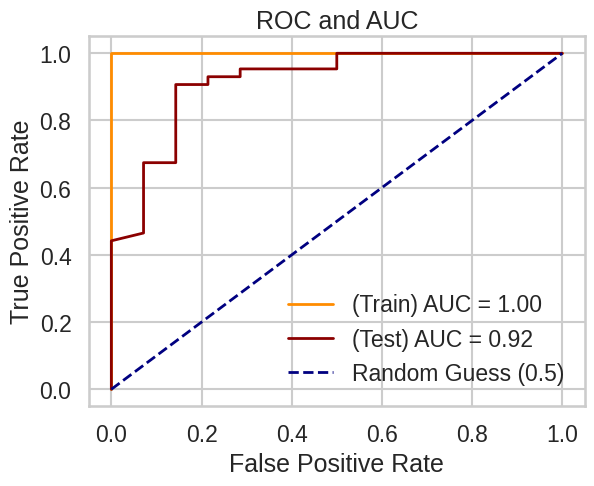

,dt_train,dt_test,dt_best_train,dt_best_test,rf_train,rf_test
metric,,,,,,
accuracy,1.0,0.807018,0.917293,0.842105,1.0,0.877193
precision,1.0,0.847826,0.924528,0.869565,1.0,0.891304
recall,1.0,0.906977,0.970297,0.930233,1.0,0.953488
f1,1.0,0.876404,0.946860,0.898876,1.0,0.921348
auc,1.0,0.703488,0.892017,0.797342,1.0,0.916113


In [ ]:
y_prob_train, y_prob_test, train_auc, test_auc = roc(t2_233523A_rf)

# record results
train_error = pd.concat([record_results(y_train, y_pred_train, train_auc, 'rf_train')], axis=1)
test_error = pd.concat([record_results(y_test, y_pred_test, test_auc, 'rf_test')], axis=1)
summary = pd.concat([summary, train_error, test_error], axis=1)
summary

In [ ]:
# as it is still a tree model, it is overfitted just as in DecisionTreeClassifier
# however, the raw score in rf is noticeably higher than that in dt

# optimize rf using grid search cv
params_rf = {
             'n_estimators': [300, 350, 400],
             'max_depth': [1, 2],
             'min_samples_leaf': [3, 4],
             'max_features': [0.8, 0.9],
             'min_samples_split': [2, 3]
            }

t2_233523A_rf_grid = GridSearchCV(estimator=RandomForestClassifier(random_state=42, oob_score=True),
                       param_grid=params_rf,
                       scoring='accuracy',
                       cv=3,
                       verbose=1,
                       n_jobs=-1)

t2_233523A_rf_grid.fit(X_train, y_train) #1.5min to run
y_pred_train, y_pred_test = evaluate(t2_233523A_rf_grid)

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Train Accuracy =  0.8721804511278195
              precision    recall  f1-score   support

       False       0.89      0.53      0.67        32
        True       0.87      0.98      0.92       101

    accuracy                           0.87       133
   macro avg       0.88      0.76      0.79       133
weighted avg       0.87      0.87      0.86       133


Test Accuracy =  0.8421052631578947
              precision    recall  f1-score   support

       False       0.86      0.43      0.57        14
        True       0.84      0.98      0.90        43

    accuracy                           0.84        57
   macro avg       0.85      0.70      0.74        57
weighted avg       0.84      0.84      0.82        57



In [ ]:
t2_233523A_rf_best = t2_233523A_rf_grid.best_estimator_
print("Best Model")
print("Best params: ", t2_233523A_rf_grid.best_params_)
print("Best OOB score: ", t2_233523A_rf_best.oob_score_)

Best Model
Best params:  {'max_depth': 1, 'max_features': 0.9, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 300}
Best OOB score:  0.8571428571428571


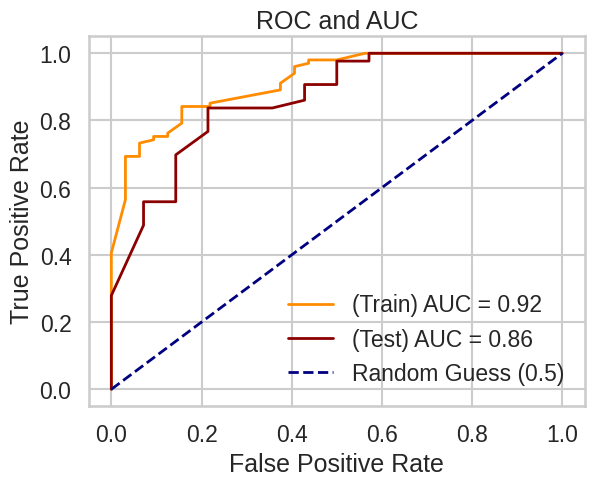

In [ ]:
# the params came out the same as the earlier decision tree model
# however, the test accuracy is higher thant that in decision tree
# compared to the raw random forest, the test accuracy dropped, but the model is not overfitted anymore
# which is what we wanted from random foest

y_prob_train, y_prob_test, train_auc, test_auc = roc(t2_233523A_rf_best)

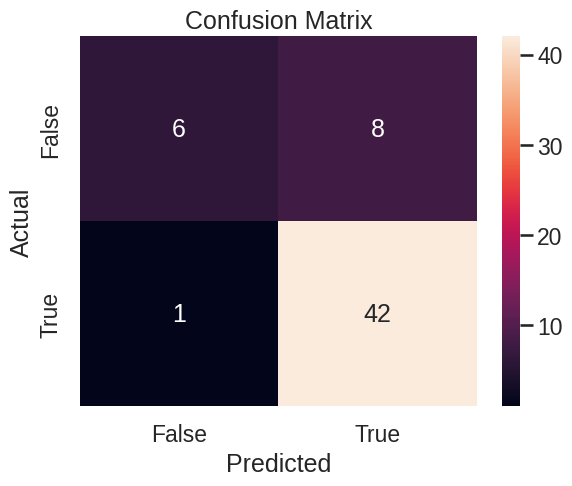

In [ ]:
cm = confusion(y_test, y_pred_test)

In [ ]:
cv_scores = cross_val(t2_233523A_rf_best)

CV Scores: [0.77777778 0.85185185 0.88888889 0.88461538 0.84615385]
Mean CV Score: 0.8498575498575498


In [ ]:
# record results
train_error = pd.concat([record_results(y_train, y_pred_train, train_auc, 'rf_best_train')], axis=1)
test_error = pd.concat([record_results(y_test, y_pred_test, test_auc, 'rf_best_test')], axis=1)
summary = pd.concat([summary, train_error, test_error], axis=1)
summary

,dt_train,dt_test,dt_best_train,dt_best_test,rf_train,rf_test,rf_best_train,rf_best_test
metric,,,,,,,,
accuracy,1.0,0.807018,0.917293,0.842105,1.0,0.877193,0.872180,0.842105
precision,1.0,0.847826,0.924528,0.869565,1.0,0.891304,0.868421,0.840000
recall,1.0,0.906977,0.970297,0.930233,1.0,0.953488,0.980198,0.976744
f1,1.0,0.876404,0.946860,0.898876,1.0,0.921348,0.920930,0.903226
auc,1.0,0.703488,0.892017,0.797342,1.0,0.916113,0.916151,0.862957


In [ ]:
# ada boost raw
t2_233523A_ab = AdaBoostClassifier(random_state=42)
t2_233523A_ab.fit(X_train, y_train)

y_pred_train, y_pred_test = evaluate(t2_233523A_ab)

Train Accuracy =  1.0
              precision    recall  f1-score   support

       False       1.00      1.00      1.00        32
        True       1.00      1.00      1.00       101

    accuracy                           1.00       133
   macro avg       1.00      1.00      1.00       133
weighted avg       1.00      1.00      1.00       133


Test Accuracy =  0.8596491228070176
              precision    recall  f1-score   support

       False       0.88      0.50      0.64        14
        True       0.86      0.98      0.91        43

    accuracy                           0.86        57
   macro avg       0.87      0.74      0.77        57
weighted avg       0.86      0.86      0.85        57



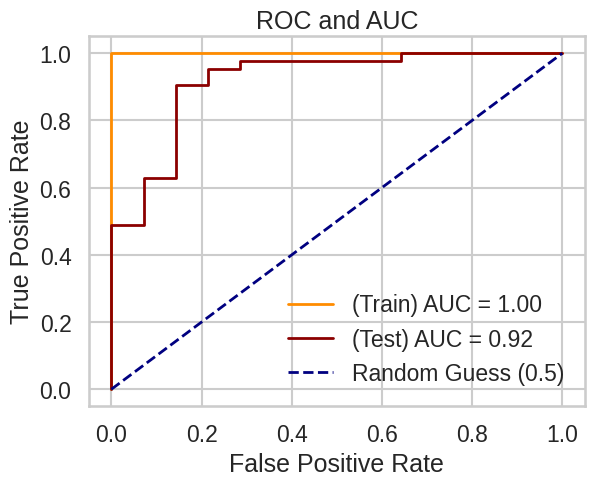

,dt_train,dt_test,dt_best_train,dt_best_test,rf_train,rf_test,rf_best_train,rf_best_test,ab_train,ab_test
metric,,,,,,,,,,
accuracy,1.0,0.807018,0.917293,0.842105,1.0,0.877193,0.872180,0.842105,1.0,0.859649
precision,1.0,0.847826,0.924528,0.869565,1.0,0.891304,0.868421,0.840000,1.0,0.857143
recall,1.0,0.906977,0.970297,0.930233,1.0,0.953488,0.980198,0.976744,1.0,0.976744
f1,1.0,0.876404,0.946860,0.898876,1.0,0.921348,0.920930,0.903226,1.0,0.913043
auc,1.0,0.703488,0.892017,0.797342,1.0,0.916113,0.916151,0.862957,1.0,0.918605


In [ ]:
y_prob_train, y_prob_test, train_auc, test_auc = roc(t2_233523A_ab)

# record results
train_error = pd.concat([record_results(y_train, y_pred_train, train_auc, 'ab_train')], axis=1)
test_error = pd.concat([record_results(y_test, y_pred_test, test_auc, 'ab_test')], axis=1)
summary = pd.concat([summary, train_error, test_error], axis=1)
summary

In [ ]:
# performs similar to RandomForestClassifier; accurate but overfitted

# optimize ab using grid search
params_ab = {
             'n_estimators': [100, 200, 250, 300],
             'learning_rate': [0.01, 0.1, 0.5],
            }

t2_233523A_ab_grid = GridSearchCV(estimator=AdaBoostClassifier(random_state=42),
                       param_grid=params_ab,
                       scoring='accuracy',
                       cv=5,
                       verbose=1,
                       n_jobs=-1)

t2_233523A_ab_grid.fit(X_train, y_train) #30s to run
y_pred_train, y_pred_test = evaluate(t2_233523A_ab_grid)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Train Accuracy =  0.8721804511278195
              precision    recall  f1-score   support

       False       0.89      0.53      0.67        32
        True       0.87      0.98      0.92       101

    accuracy                           0.87       133
   macro avg       0.88      0.76      0.79       133
weighted avg       0.87      0.87      0.86       133


Test Accuracy =  0.8421052631578947
              precision    recall  f1-score   support

       False       0.86      0.43      0.57        14
        True       0.84      0.98      0.90        43

    accuracy                           0.84        57
   macro avg       0.85      0.70      0.74        57
weighted avg       0.84      0.84      0.82        57



In [ ]:
# overfitting is significantly reduced for a slight trade off in accuracy

t2_233523A_ab_best = t2_233523A_ab_grid.best_estimator_
print("Best Model")
print("Best params: ", t2_233523A_ab_grid.best_params_)

Best Model
Best params:  {'learning_rate': 0.01, 'n_estimators': 100}


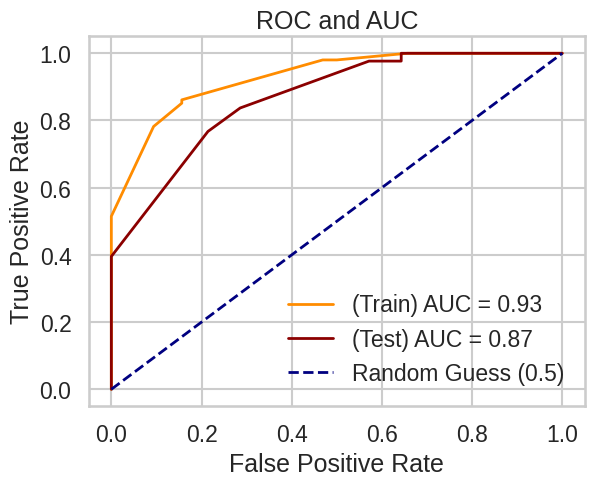

In [ ]:
# as a complex model is used, a bigger learning rate and less number of estimators are expected here
# and it came out as expected

y_prob_train, y_prob_test, train_auc, test_auc = roc(t2_233523A_ab_best)

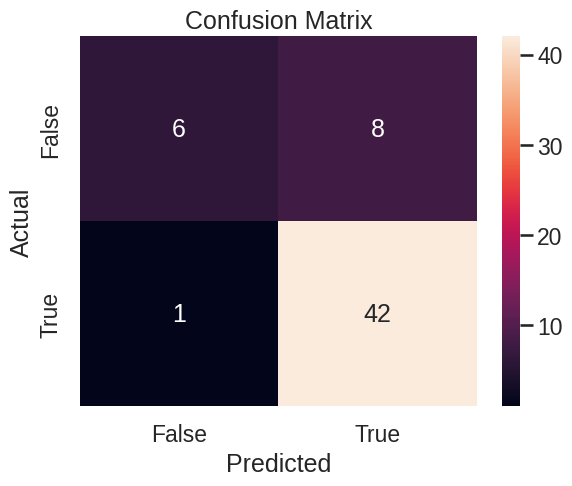

In [ ]:
cm = confusion(y_test, y_pred_test)

In [ ]:
# AdaBoost is also weak in capturing 'False' status unseen pattern

# record results
train_error = pd.concat([record_results(y_train, y_pred_train, train_auc, 'ab_best_train')], axis=1)
test_error = pd.concat([record_results(y_test, y_pred_test, test_auc, 'ab_best_test')], axis=1)
summary = pd.concat([summary, train_error, test_error], axis=1)
summary.T

,dt_train,dt_test,dt_best_train,dt_best_test,rf_train,rf_test,rf_best_train,rf_best_test,ab_train,ab_test,ab_best_train,ab_best_test
metric,,,,,,,,,,,,
accuracy,1.0,0.807018,0.917293,0.842105,1.0,0.877193,0.872180,0.842105,1.0,0.859649,0.872180,0.842105
precision,1.0,0.847826,0.924528,0.869565,1.0,0.891304,0.868421,0.840000,1.0,0.857143,0.868421,0.840000
recall,1.0,0.906977,0.970297,0.930233,1.0,0.953488,0.980198,0.976744,1.0,0.976744,0.980198,0.976744
f1,1.0,0.876404,0.946860,0.898876,1.0,0.921348,0.920930,0.903226,1.0,0.913043,0.920930,0.903226
auc,1.0,0.703488,0.892017,0.797342,1.0,0.916113,0.916151,0.862957,1.0,0.918605,0.928682,0.867940


In [ ]:
cv_scores = cross_val(t2_233523A_ab_best)

CV Scores: [0.77777778 0.85185185 0.85185185 0.84615385 0.88461538]
Mean CV Score: 0.8424501424501425


In [ ]:
# svc raw
t2_233523A_svc = SVC(random_state=42, probability=True)
t2_233523A_svc.fit(X_train, y_train)

y_pred_train, y_pred_test = evaluate(t2_233523A_svc)

Train Accuracy =  0.8947368421052632
              precision    recall  f1-score   support

       False       0.95      0.59      0.73        32
        True       0.88      0.99      0.93       101

    accuracy                           0.89       133
   macro avg       0.92      0.79      0.83       133
weighted avg       0.90      0.89      0.89       133


Test Accuracy =  0.8421052631578947
              precision    recall  f1-score   support

       False       0.78      0.50      0.61        14
        True       0.85      0.95      0.90        43

    accuracy                           0.84        57
   macro avg       0.82      0.73      0.75        57
weighted avg       0.84      0.84      0.83        57



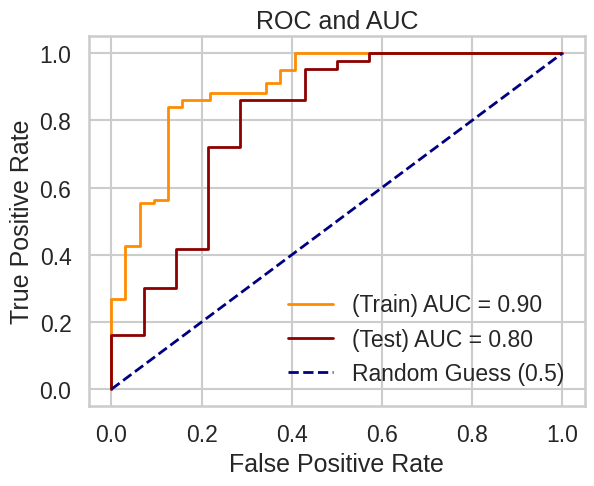

,dt_train,dt_test,dt_best_train,dt_best_test,rf_train,rf_test,rf_best_train,rf_best_test,ab_train,ab_test,ab_best_train,ab_best_test,svc_train,svc_test
metric,,,,,,,,,,,,,,
accuracy,1.0,0.807018,0.917293,0.842105,1.0,0.877193,0.872180,0.842105,1.0,0.859649,0.872180,0.842105,0.894737,0.842105
precision,1.0,0.847826,0.924528,0.869565,1.0,0.891304,0.868421,0.840000,1.0,0.857143,0.868421,0.840000,0.884956,0.854167
recall,1.0,0.906977,0.970297,0.930233,1.0,0.953488,0.980198,0.976744,1.0,0.976744,0.980198,0.976744,0.990099,0.953488
f1,1.0,0.876404,0.946860,0.898876,1.0,0.921348,0.920930,0.903226,1.0,0.913043,0.920930,0.903226,0.934579,0.901099
auc,1.0,0.703488,0.892017,0.797342,1.0,0.916113,0.916151,0.862957,1.0,0.918605,0.928682,0.867940,0.898824,0.803987


In [ ]:
# as expected of a model that works well with multidimentional data
# the test accuracy is good and the model is only slightly overfitted

y_prob_train, y_prob_test, train_auc, test_auc = roc(t2_233523A_svc)

# record results
train_error = pd.concat([record_results(y_train, y_pred_train, train_auc, 'svc_train')], axis=1)
test_error = pd.concat([record_results(y_test, y_pred_test, test_auc, 'svc_test')], axis=1)
summary = pd.concat([summary, train_error, test_error], axis=1)
summary.T

In [ ]:
# optimize in the same way
param_svc = {
    'C': [0.01, 0.05, 0.1],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
}

t2_233523A_svc_grid = GridSearchCV(estimator=SVC(random_state=42, probability=True),
                           param_grid=param_svc,
                           cv=5,
                           n_jobs=-1,
                           verbose=1)

t2_233523A_svc_grid.fit(X_train, y_train)
y_pred_train, y_pred_test = evaluate(t2_233523A_svc_grid)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Train Accuracy =  0.8947368421052632
              precision    recall  f1-score   support

       False       0.95      0.59      0.73        32
        True       0.88      0.99      0.93       101

    accuracy                           0.89       133
   macro avg       0.92      0.79      0.83       133
weighted avg       0.90      0.89      0.89       133


Test Accuracy =  0.8596491228070176
              precision    recall  f1-score   support

       False       0.80      0.57      0.67        14
        True       0.87      0.95      0.91        43

    accuracy                           0.86        57
   macro avg       0.84      0.76      0.79        57
weighted avg       0.85      0.86      0.85        57



In [ ]:
t2_233523A_svc_best = t2_233523A_svc_grid.best_estimator_
print("Best Model")
print("Best params: ", t2_233523A_svc_grid.best_params_)

Best Model
Best params:  {'C': 0.05, 'gamma': 'scale', 'kernel': 'linear'}


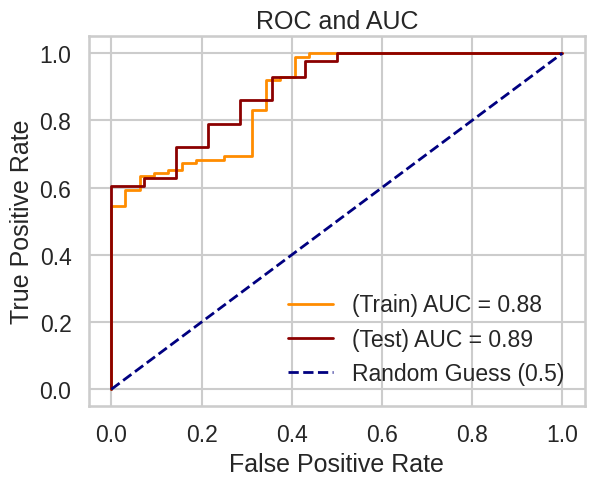

In [ ]:
y_prob_train, y_prob_test, train_auc, test_auc = roc(t2_233523A_svc_best)

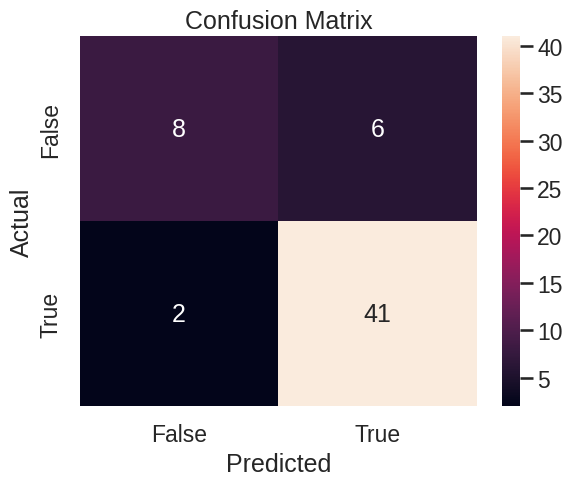

In [ ]:
cm = confusion(y_test, y_pred_test)

In [ ]:
cv_scores = cross_val(t2_233523A_svc_best)

CV Scores: [0.81481481 0.85185185 0.88888889 0.96153846 0.88461538]
Mean CV Score: 0.8803418803418804


In [ ]:
# record results
train_error = pd.concat([record_results(y_train, y_pred_train, train_auc, 'svc_best_train')], axis=1)
test_error = pd.concat([record_results(y_test, y_pred_test, test_auc, 'svc_best_test')], axis=1)
summary = pd.concat([summary, train_error, test_error], axis=1)
summary.T

metric,accuracy,precision,recall,f1,auc
dt_train,1.000000,1.000000,1.000000,1.000000,1.000000
dt_test,0.807018,0.847826,0.906977,0.876404,0.703488
dt_best_train,0.917293,0.924528,0.970297,0.946860,0.892017
dt_best_test,0.842105,0.869565,0.930233,0.898876,0.797342
rf_train,1.000000,1.000000,1.000000,1.000000,1.000000
rf_test,0.877193,0.891304,0.953488,0.921348,0.916113
rf_best_train,0.872180,0.868421,0.980198,0.920930,0.916151
rf_best_test,0.842105,0.840000,0.976744,0.903226,0.862957
ab_train,1.000000,1.000000,1.000000,1.000000,1.000000
ab_test,0.859649,0.857143,0.976744,0.913043,0.918605


In [ ]:
# time for the final ensemble
# raw staking classifier
t2_233523A_stack = StackingClassifier(
    estimators=[
        ('rf', t2_233523A_rf_best),
        ('ab', t2_233523A_ab_best),
        ('svc', t2_233523A_svc_best)
    ],
    final_estimator=GradientBoostingClassifier(random_state=42),
    cv=5)

t2_233523A_stack.fit(X_train, y_train)
y_pred_train, y_pred_test = evaluate(t2_233523A_stack)

Train Accuracy =  0.8947368421052632
              precision    recall  f1-score   support

       False       0.85      0.69      0.76        32
        True       0.91      0.96      0.93       101

    accuracy                           0.89       133
   macro avg       0.88      0.82      0.85       133
weighted avg       0.89      0.89      0.89       133


Test Accuracy =  0.8596491228070176
              precision    recall  f1-score   support

       False       0.75      0.64      0.69        14
        True       0.89      0.93      0.91        43

    accuracy                           0.86        57
   macro avg       0.82      0.79      0.80        57
weighted avg       0.85      0.86      0.86        57



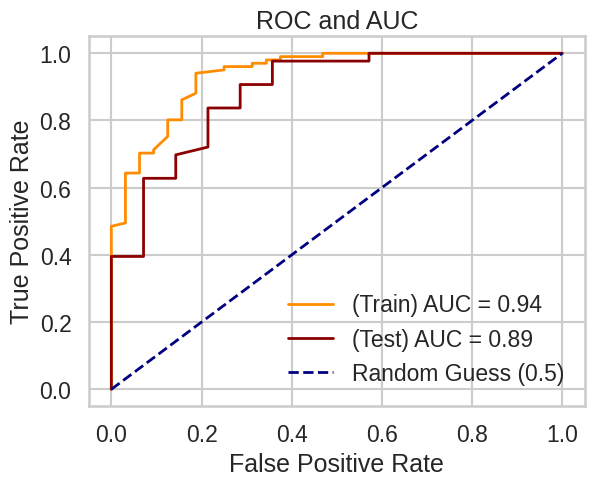

,dt_train,dt_test,dt_best_train,dt_best_test,rf_train,rf_test,rf_best_train,rf_best_test,ab_train,ab_test,ab_best_train,ab_best_test,svc_train,svc_test,svc_best_train,svc_best_test,stack_train,stack_test
metric,,,,,,,,,,,,,,,,,,
accuracy,1.0,0.807018,0.917293,0.842105,1.0,0.877193,0.872180,0.842105,1.0,0.859649,0.872180,0.842105,0.894737,0.842105,0.894737,0.859649,0.894737,0.859649
precision,1.0,0.847826,0.924528,0.869565,1.0,0.891304,0.868421,0.840000,1.0,0.857143,0.868421,0.840000,0.884956,0.854167,0.884956,0.872340,0.906542,0.888889
recall,1.0,0.906977,0.970297,0.930233,1.0,0.953488,0.980198,0.976744,1.0,0.976744,0.980198,0.976744,0.990099,0.953488,0.990099,0.953488,0.960396,0.930233
f1,1.0,0.876404,0.946860,0.898876,1.0,0.921348,0.920930,0.903226,1.0,0.913043,0.920930,0.903226,0.934579,0.901099,0.934579,0.911111,0.932692,0.909091
auc,1.0,0.703488,0.892017,0.797342,1.0,0.916113,0.916151,0.862957,1.0,0.918605,0.928682,0.867940,0.898824,0.803987,0.880260,0.893688,0.936726,0.886213


In [ ]:
y_prob_train, y_prob_test, train_auc, test_auc = roc(t2_233523A_stack)

# record results
train_error = pd.concat([record_results(y_train, y_pred_train, train_auc, 'stack_train')], axis=1)
test_error = pd.concat([record_results(y_test, y_pred_test, test_auc, 'stack_test')], axis=1)
summary = pd.concat([summary, train_error, test_error], axis=1)
summary.T

In [ ]:
# final optimization of the meta classifier
param_stack = {
    'final_estimator__n_estimators': [50, 100, 200],
    'final_estimator__learning_rate': [0.005, 0.01, 0.1],
}

sclf = StackingClassifier(
    estimators=[
        ('rf', t2_233523A_rf_best),
        ('ab', t2_233523A_ab_best),
        ('svc', t2_233523A_svc_best)
    ],
    final_estimator=GradientBoostingClassifier(random_state=42))

t2_233523A_stack_grid = GridSearchCV(estimator=sclf, param_grid=param_stack, cv=3, n_jobs=-1, verbose=1)

t2_233523A_stack_grid.fit(X_train, y_train) #3min to run as it is a GridSearch on 3 models
y_pred_train, y_pred_test = evaluate(t2_233523A_stack_grid)

Fitting 3 folds for each of 9 candidates, totalling 27 fits
Train Accuracy =  0.9323308270676691
              precision    recall  f1-score   support

       False       0.96      0.75      0.84        32
        True       0.93      0.99      0.96       101

    accuracy                           0.93       133
   macro avg       0.94      0.87      0.90       133
weighted avg       0.93      0.93      0.93       133


Test Accuracy =  0.8771929824561403
              precision    recall  f1-score   support

       False       0.89      0.57      0.70        14
        True       0.88      0.98      0.92        43

    accuracy                           0.88        57
   macro avg       0.88      0.77      0.81        57
weighted avg       0.88      0.88      0.87        57



In [ ]:
t2_233523A_stack_best = t2_233523A_stack_grid.best_estimator_
print("Best Model")
print("Best params: ", t2_233523A_stack_grid.best_params_)

Best Model
Best params:  {'final_estimator__learning_rate': 0.005, 'final_estimator__n_estimators': 200}


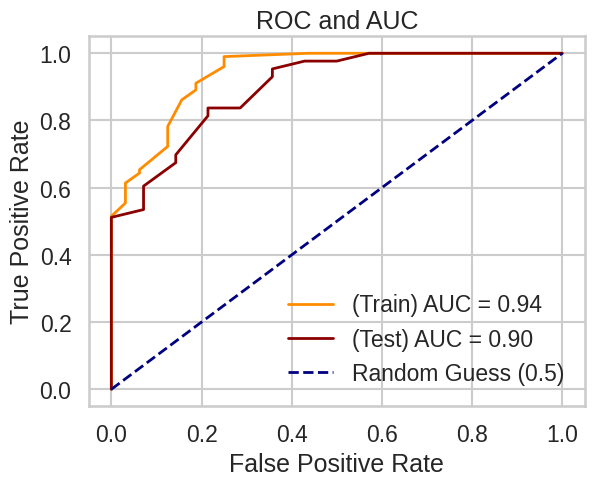

In [ ]:
y_prob_train, y_prob_test, train_auc, test_auc = roc(t2_233523A_stack_best)

In [ ]:
cv_scores = cross_val(t2_233523A_stack_best) #takes 1min

CV Scores: [0.77777778 0.85185185 0.85185185 0.92307692 0.88461538]
Mean CV Score: 0.8578347578347578


In [ ]:
# record results
train_error = pd.concat([record_results(y_train, y_pred_train, train_auc, 'stack_best_train')], axis=1)
test_error = pd.concat([record_results(y_test, y_pred_test, test_auc, 'stack_best_test')], axis=1)
summary = pd.concat([summary, train_error, test_error], axis=1)
summary.T.tail()

metric,accuracy,precision,recall,f1,auc
svc_best_test,0.859649,0.872340,0.953488,0.911111,0.893688
stack_train,0.894737,0.906542,0.960396,0.932692,0.936726
stack_test,0.859649,0.888889,0.930233,0.909091,0.886213
stack_best_train,0.932331,0.925926,0.990099,0.956938,0.939975
stack_best_test,0.877193,0.875000,0.976744,0.923077,0.897841


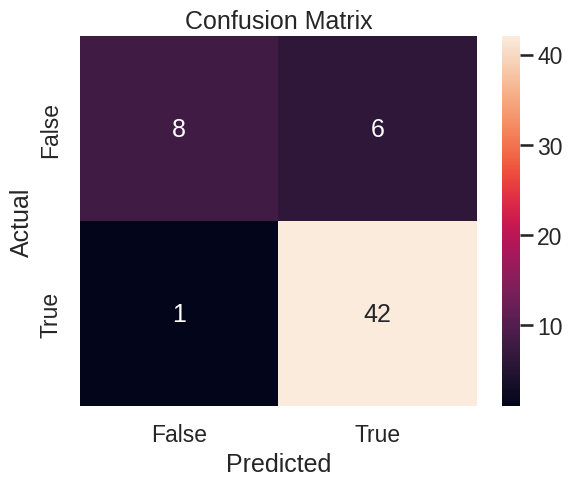

array([[ 8,  6],
       [ 1, 42]])

In [ ]:
confusion(y_test, y_pred_test)

# Summary of Ensemble Model

In [ ]:
summary.iloc[:, 4:].T

metric,accuracy,precision,recall,f1,auc
rf_train,1.000000,1.000000,1.000000,1.000000,1.000000
rf_test,0.877193,0.891304,0.953488,0.921348,0.916113
rf_best_train,0.872180,0.868421,0.980198,0.920930,0.916151
rf_best_test,0.842105,0.840000,0.976744,0.903226,0.862957
ab_train,1.000000,1.000000,1.000000,1.000000,1.000000
ab_test,0.859649,0.857143,0.976744,0.913043,0.918605
ab_best_train,0.872180,0.868421,0.980198,0.920930,0.928682
ab_best_test,0.842105,0.840000,0.976744,0.903226,0.867940
svc_train,0.894737,0.884956,0.990099,0.934579,0.898824
svc_test,0.842105,0.854167,0.953488,0.901099,0.803987


In [ ]:
summary = summary.T.reset_index()
summary.columns = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
summary

,Model,Accuracy,Precision,Recall,F1,AUC
0,dt_train,1.000000,1.000000,1.000000,1.000000,1.000000
1,dt_test,0.807018,0.847826,0.906977,0.876404,0.703488
2,dt_best_train,0.917293,0.924528,0.970297,0.946860,0.892017
3,dt_best_test,0.842105,0.869565,0.930233,0.898876,0.797342
4,rf_train,1.000000,1.000000,1.000000,1.000000,1.000000
5,rf_test,0.877193,0.891304,0.953488,0.921348,0.916113
6,rf_best_train,0.872180,0.868421,0.980198,0.920930,0.916151
7,rf_best_test,0.842105,0.840000,0.976744,0.903226,0.862957
8,ab_train,1.000000,1.000000,1.000000,1.000000,1.000000
9,ab_test,0.859649,0.857143,0.976744,0.913043,0.918605


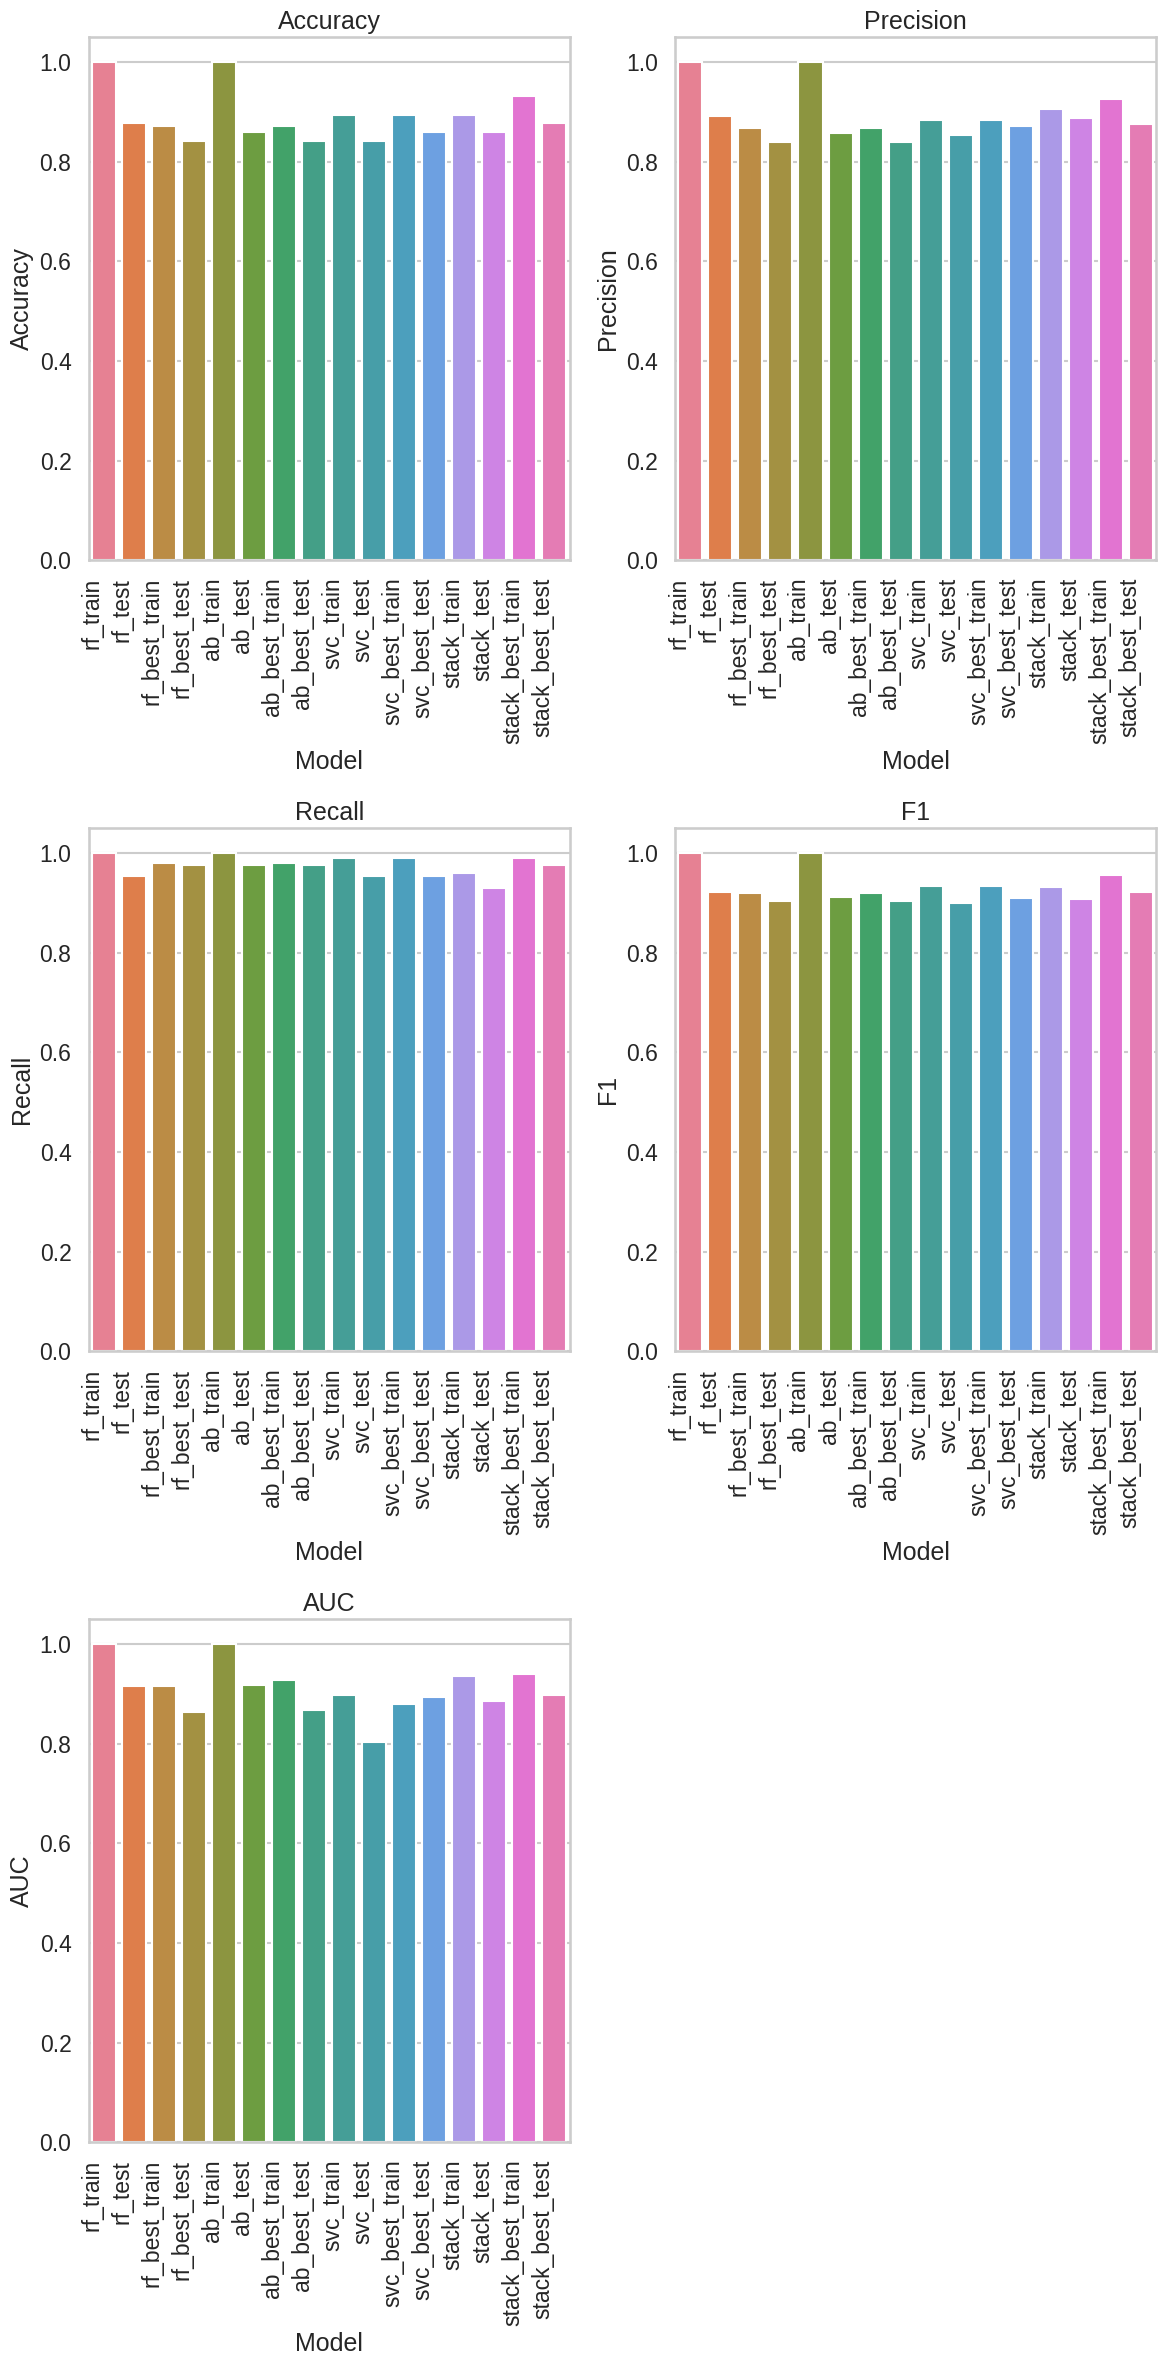

In [ ]:
ensemble_summary = summary.iloc[4:, :]

# plot
fig, axes = plt.subplots(3, 2, figsize=(12, 24))
(ax1, ax2), (ax3, ax4), (ax5, ax6) = axes
sns.barplot(data=ensemble_summary, x='Model', y='Accuracy', hue='Model', ax=ax1)
ax1.set_title('Accuracy')
sns.barplot(data=ensemble_summary, x='Model', y='Precision', hue='Model', ax=ax2)
ax2.set_title('Precision')
sns.barplot(data=ensemble_summary, x='Model', y='Recall', hue='Model', ax=ax3)
ax3.set_title('Recall')
sns.barplot(data=ensemble_summary, x='Model', y='F1', hue='Model', ax=ax4)
ax4.set_title('F1')
sns.barplot(data=ensemble_summary, x='Model', y='AUC', hue='Model', ax=ax5)
ax5.set_title('AUC')
ax6.axis('off')
for ax in axes.flat:
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="right")
plt.tight_layout()
plt.savefig('ensemble_summary.png')
plt.show()

[145 words]

1.   **Stacking Ensemble method** has been used to have a heterogenous model by taking the best characteristics from individual models.
2.   Three based models chosen are: **RandomForestClassifier** for its extra randomness on top of Bagging, **AdaBoost** as this is a binary classification of imbalanced label distribution, and **SupportVectorClassifier** for its exceptional performace on high-dimensional datxa.
3.  Each of these models are tained, optimized and regularized through different sets of GridSearchCV to balance the bias and variance while maintaining acceptable accuracy.
4.  **GradientBoostingClassifier** is then used as the meta classifier of the **StackingClassifier** to soft-vote the class of 'status'.
5.  As shown above, the fine-tuned base models perform similar to or only slightly worse than the ensemble model. (SVC even outperforming ensemble in some metrics.)
6.  However, the noticeable thing is the ensemble method obtained the highest recall score, which neither of the individual models could.



# Comparison of the Two Models

In [ ]:
main = summary.iloc[[2, 3, 18, 19], :].reset_index(drop=True)
main

,Model,Accuracy,Precision,Recall,F1,AUC
0,dt_best_train,0.917293,0.924528,0.970297,0.946860,0.892017
1,dt_best_test,0.842105,0.869565,0.930233,0.898876,0.797342
2,stack_best_train,0.932331,0.925926,0.990099,0.956938,0.939975
3,stack_best_test,0.877193,0.875000,0.976744,0.923077,0.897841


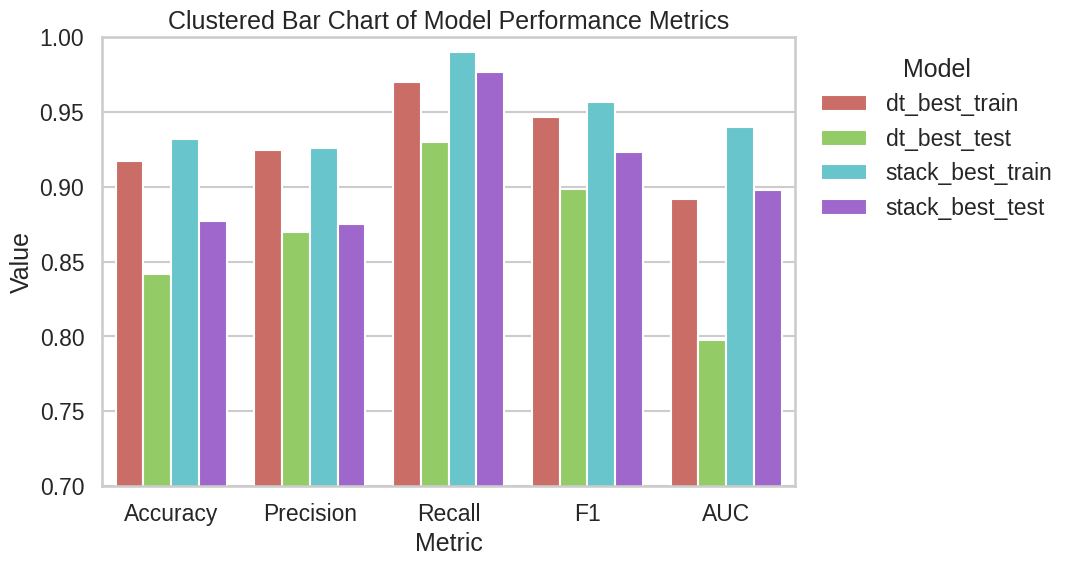

In [ ]:
metrics = ["Accuracy", "Precision", "Recall", "F1", "AUC"]

plt.figure(figsize=(12, 6))
sns.barplot(x="Metric", y="Value", hue="Model", palette='hls',
            data=pd.melt(main, id_vars=["Model"], value_vars=metrics, var_name="Metric", value_name="Value"))

plt.title("Clustered Bar Chart of Model Performance Metrics")
plt.xlabel("Metric")
plt.ylabel("Value")
plt.ylim(0.7, 1)
plt.legend(title="Model", loc='upper right', bbox_to_anchor=(1.4, 1))
plt.tight_layout()
plt.show()

[183 words]

1.  As shown above, the StackingClassifier performed noticeably better than the DecisionTree in almost every metric except precision, where the DecisionTree performed equally well. The ensemble worked as expected in reducing variance while increasing accuracy.
2.  However, the ensemble, especially the StackingClassifier, is much more resource-consuming than the DecisionTree; some codes took 2-3 minutes to run, while the DecisionTree was lightweight.
3.  Despite the decision tree’s faster execution, its lower test accuracy (0.84 vs. 0.88 for the ensemble) suggests that it may not generalize as well. In Parkinson’s diagnosis, this could mean fewer correctly identified patients, impacting treatment decisions.
4.  Given this is a disease classification task, it’s better to spend more resources on a better-performing model.
5.  Referring to the classification reports, most models have good precision for the ‘False’ class, but recall is quite low (some even ~0.5). This suggests the models may miss many actual ‘False’ cases, potentially leading to underdiagnosis.
6.  If a higher recall is preferred to ensure early diagnosis, the decision threshold can be adjusted for the ensemble model as shown in the DecisionTreeClassifier.




# Experimental

In [ ]:
# SVC performs quite well with less resource consumption compared to StackingClassifier
# let us try it out with the original high-dimentional data and the imputed data

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 190 entries, 0 to 189
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MDVP:Fo(Hz)       190 non-null    float64
 1   MDVP:Fhi(Hz)      190 non-null    float64
 2   MDVP:Flo(Hz)      190 non-null    float64
 3   MDVP:Jitter(%)    190 non-null    float64
 4   MDVP:Jitter(Abs)  190 non-null    float64
 5   MDVP:RAP          190 non-null    float64
 6   MDVP:PPQ          190 non-null    float64
 7   Jitter:DDP        190 non-null    float64
 8   MDVP:Shimmer      190 non-null    float64
 9   MDVP:Shimmer(dB)  190 non-null    float64
 10  Shimmer:APQ3      190 non-null    float64
 11  Shimmer:APQ5      190 non-null    float64
 12  MDVP:APQ          190 non-null    float64
 13  Shimmer:DDA       190 non-null    float64
 14  NHR               190 non-null    float64
 15  HNR               190 non-null    float64
 16  status            190 non-null    bool   
 1

In [ ]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192 entries, 0 to 191
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   D2                192 non-null    float64
 1   DFA               192 non-null    float64
 2   HNR               192 non-null    float64
 3   Jitter:DDP        192 non-null    float64
 4   MDVP:APQ          192 non-null    float64
 5   MDVP:Fhi(Hz)      192 non-null    float64
 6   MDVP:Flo(Hz)      192 non-null    float64
 7   MDVP:Fo(Hz)       192 non-null    float64
 8   MDVP:Jitter(%)    192 non-null    float64
 9   MDVP:Jitter(Abs)  192 non-null    float64
 10  MDVP:PPQ          192 non-null    float64
 11  MDVP:RAP          192 non-null    float64
 12  MDVP:Shimmer      192 non-null    float64
 13  MDVP:Shimmer(dB)  192 non-null    float64
 14  NHR               192 non-null    float64
 15  PPE               192 non-null    float64
 16  RPDE              192 non-null    float64
 1

In [ ]:
svc_test = SVC(random_state=42, probability=True)
svc_test.fit(X_train, y_train)

print("SVC on original non-scaled, non-PCA data:")
y_pred_train, y_pred_test = evaluate(svc_test)

SVC on original non-scaled, non-PCA data:
Train Accuracy =  0.8947368421052632
              precision    recall  f1-score   support

       False       0.95      0.59      0.73        32
        True       0.88      0.99      0.93       101

    accuracy                           0.89       133
   macro avg       0.92      0.79      0.83       133
weighted avg       0.90      0.89      0.89       133


Test Accuracy =  0.8421052631578947
              precision    recall  f1-score   support

       False       0.78      0.50      0.61        14
        True       0.85      0.95      0.90        43

    accuracy                           0.84        57
   macro avg       0.82      0.73      0.75        57
weighted avg       0.84      0.84      0.83        57



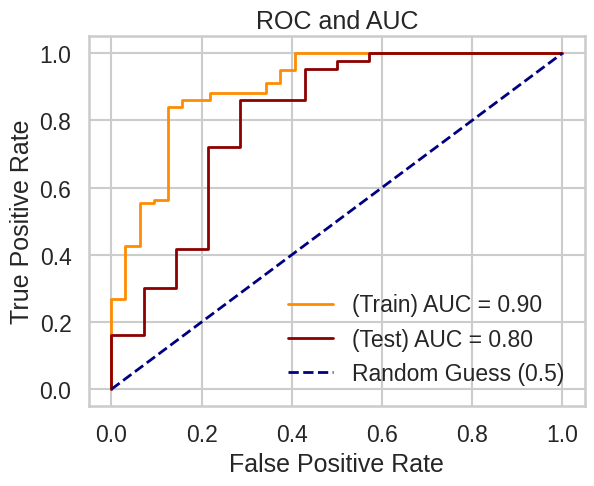

In [ ]:
# similar to that done on pca data; pca is valid

y_prob_train, y_prob_test, train_auc, test_auc = roc(svc_test)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Train Accuracy =  0.8947368421052632
              precision    recall  f1-score   support

       False       0.95      0.59      0.73        32
        True       0.88      0.99      0.93       101

    accuracy                           0.89       133
   macro avg       0.92      0.79      0.83       133
weighted avg       0.90      0.89      0.89       133


Test Accuracy =  0.8596491228070176
              precision    recall  f1-score   support

       False       0.80      0.57      0.67        14
        True       0.87      0.95      0.91        43

    accuracy                           0.86        57
   macro avg       0.84      0.76      0.79        57
weighted avg       0.85      0.86      0.85        57



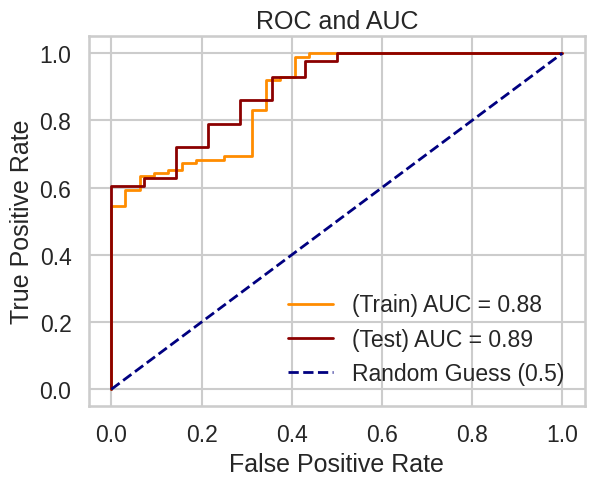

In [ ]:
# optimize
param_svc = {
    'C': [0.01, 0.05, 0.1],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
}

svc_test_grid = GridSearchCV(estimator=SVC(random_state=42, probability=True),
                           param_grid=param_svc,
                           cv=5,
                           n_jobs=-1,
                           verbose=1)

svc_test_grid.fit(X_train, y_train)
y_pred_train, y_pred_test = evaluate(svc_test_grid)
y_prob_train, y_prob_test, train_auc, test_auc = roc(svc_test_grid)

In [ ]:
# similar results to RandomForest; ROC curve is better, not overfitted

# test the validity of imputed data
svc_test2 = SVC(random_state=42, probability=True)
svc_test2.fit(X_train, y_train)

print("SVC on imputed non-scaled, non-PCA data:")
y_pred_train, y_pred_test = evaluate(svc_test2)

SVC on imputed non-scaled, non-PCA data:
Train Accuracy =  0.8947368421052632
              precision    recall  f1-score   support

       False       0.95      0.59      0.73        32
        True       0.88      0.99      0.93       101

    accuracy                           0.89       133
   macro avg       0.92      0.79      0.83       133
weighted avg       0.90      0.89      0.89       133


Test Accuracy =  0.8421052631578947
              precision    recall  f1-score   support

       False       0.78      0.50      0.61        14
        True       0.85      0.95      0.90        43

    accuracy                           0.84        57
   macro avg       0.82      0.73      0.75        57
weighted avg       0.84      0.84      0.83        57



In [ ]:
# oh well, it was only two roles that were imputed, so no difference